# Dynamic and Hybrid Conditioning for Compositional Image Retrieval

**Deep Learning 2026 — Project notebook**

*Team: Matteo Pareto, Elena Deidda*

---

## Abstract

Given a reference face image $v_{ref}$ and a set of textual attribute constraints
(positive, e.g. `+Eyeglasses`, or negative, e.g. `-Smiling`), the task is to retrieve,
from the CelebA test split (19,962 images), the images that **preserve the identity of the
reference** while **satisfying every constraint**.

We build three methods of increasing sophistication and compare them on the official
benchmark (`celeba_evaluation.json`, Recall@K / Precision@K at $K \in \{1, 5, 10\}$):

1. **Level 1 — Zero-shot latent arithmetic** (mandatory baseline): $\hat q = \mathrm{norm}(v_{ref} + \sum_i s_i\, t_i)$.
2. **Level 2 — Visual attribute directions** (training-free): replaces cross-modal text
   arithmetic with intra-modal attribute directions estimated from the CelebA *train* split,
   optionally composed on the unit sphere via logarithmic/exponential maps.
3. **Level 3 — Gated cross-attention fusion** (training-based, our main contribution):
   a lightweight learned module (~4M params, frozen CLIP) that *dynamically* weighs the
   conditions with cross-attention and controls the modification strength with a learned
   gate, trained with InfoNCE on triplets mined from the train split with the same
   relaxed-Hamming rule used to build the benchmark.

---

## How to run / debugging checklist

The notebook is designed to be debugged **one section at a time, top to bottom**.
Every expensive artifact is cached on Google Drive, so re-running is cheap.

| Section | What to verify before moving on | Expected cost (Colab T4) |
|---|---|---|
| §1–2 Setup + data | `len(test) == 19962`, `len(train) == 162770`, 40 attributes | ~2 min (unzip) |
| §3 Embeddings | shapes `(19962, 512)` / `(162770, 512)`, rows unit-norm | ~5 min + ~35 min, **once** (then cached) |
| §4 Benchmark | all 14 queries parse, harness self-test passes | seconds |
| §5 Level 1 | macro R@10 well above random chance (~1.3%) | ~1 min |
| §6 Level 2 | beats Level 1 on macro R@10 | ~1 min |
| §7 Level 3 | training loss decreases, synthetic val R@10 improves, then beats Level 2 on the benchmark | ~5 min mining + ~10 min training, cached |
| §8 Results | comparative tables + CIs/significance + qualitative examples | ~3 min |
| §9 Custom queries | entries built with the official rule; source counts printed | ~3 min |

> **Tip:** set `SMOKE_TEST = True` in the config cell for a first fast end-to-end run
> (fewer benchmark sources, fewer training examples, 2 epochs). Set it back to `False`
> for the real numbers. Smoke artifacts are cached under different filenames.


## 1. Environment setup

The notebook runs on Google Colab (GPU runtime recommended). It expects on Google Drive,
inside `MyDrive/datasets/`:

- `celeba.zip` — the CelebA dataset (provided by the course),
- `celeba_evaluation.json` — the official benchmark file.

All caches (CLIP embeddings, mined training examples, model checkpoint) are written to the
same Drive folder so they survive runtime disconnections.

**Running outside Colab (e.g. on an Azure GPU VM):** the notebook falls back to local
paths — `celeba.zip`, `celeba_evaluation.json` and all caches live in the repo's
`database/` folder, and the dataset is extracted automatically into `./datasets/`.
Launch Jupyter from the repo root (or set the `DL_PROJECT_ROOT` environment variable to
point at it). The `.pt` cache files are portable between environments. Step-by-step
instructions for both environments, including Azure VM provisioning, are in `RUNNING.md`.

In [1]:
%pip install -q transformers accelerate


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: /home/disi/DL-ParetoDeidda/.venv/bin/python -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
import json
import math
import os
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Subset
from tqdm.auto import tqdm

IN_COLAB = "google.colab" in sys.modules

# --- Paths -----------------------------------------------------------------
if IN_COLAB:
    DRIVE_DIR = Path("/content/drive/MyDrive/datasets")  # zip, benchmark JSON, caches
    DATA_ROOT = Path("/content/datasets")                # fast local SSD (wiped on disconnect)
else:
    # VM / local machine: everything lives inside the repo. Paths resolve
    # against the repo root — launch Jupyter from the repo root, or point
    # DL_PROJECT_ROOT at it explicitly (see RUNNING.md).
    ROOT = Path(os.environ.get("DL_PROJECT_ROOT", ".")).resolve()
    DRIVE_DIR = ROOT / "database"                        # zip, benchmark JSON, caches
    DATA_ROOT = ROOT / "datasets"

EVAL_JSON_PATH = DRIVE_DIR / "celeba_evaluation.json"
MODEL_NAME = "openai/clip-vit-base-patch32"              # mandatory model for the assignment

# --- Global switches ---------------------------------------------------------
SEED = 42
K_VALUES = (1, 5, 10)     # evaluation cutoffs required by the assignment
SMOKE_TEST = False        # True = fast reduced run to debug the whole pipeline
SMOKE_SUFFIX = "_smoke" if SMOKE_TEST else ""

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if device.type == "cuda":
    torch.cuda.manual_seed_all(SEED)

# Fixed categorical colors for all charts (validated colorblind-safe palette)
METHOD_COLORS = {
    "L1 zero-shot arithmetic": "#2a78d6",             # blue
    "L2 visual directions": "#1baf7a",                # aqua
    "L3 gated cross-attention": "#eda100",            # yellow
    "L2 visual directions (linear ablation)": "#008300",  # green
}

print(f"Colab: {IN_COLAB} | device: {device} | smoke test: {SMOKE_TEST}")

Colab: False | device: cuda | smoke test: False


In [3]:
# Dataset preparation — same cell for Colab and for a VM/local machine.
# Inputs expected in DRIVE_DIR: celeba.zip and celeba_evaluation.json.
# On Colab DRIVE_DIR is Google Drive; on a VM it is the repo's database/ folder.
import shutil
import zipfile

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

celeba_dir = DATA_ROOT / "celeba"
# Everything torchvision's CelebA validates at init (root must be the PARENT
# of celeba/): the image folder plus the five MD5-checked metadata files.
REQUIRED = [
    "img_align_celeba",
    "list_attr_celeba.txt",
    "list_eval_partition.txt",
    "identity_CelebA.txt",
    "list_bbox_celeba.txt",
    "list_landmarks_align_celeba.txt",
]


def dataset_complete():
    return all((celeba_dir / f).exists() for f in REQUIRED)


# A marker distinguishes a completed extraction from a partial one left by an
# interrupted run (the celeba/ folder appears before extraction finishes).
done_marker = celeba_dir / ".unzip_done"
if not done_marker.exists() and not dataset_complete():
    zip_path = DRIVE_DIR / "celeba.zip"
    assert zip_path.exists(), (
        f"Dataset archive not found: {zip_path}\n"
        "- Colab: put celeba.zip in MyDrive/datasets/ (course-provided file).\n"
        "- VM/local: copy celeba.zip into the repo's database/ folder.\n"
        "See RUNNING.md for step-by-step instructions."
    )
    DATA_ROOT.mkdir(parents=True, exist_ok=True)
    print(f"Extracting {zip_path} -> {DATA_ROOT} (a few minutes)...")
    if shutil.which("unzip"):  # fast native path
        import subprocess
        subprocess.run(["unzip", "-q", str(zip_path), "-d", str(DATA_ROOT)],
                       check=True)
    else:                      # portable fallback, no external binary needed
        with zipfile.ZipFile(zip_path) as zf:
            zf.extractall(DATA_ROOT)
    done_marker.touch()

assert dataset_complete(), (
    f"Dataset folder incomplete under {celeba_dir} — missing: "
    f"{[f for f in REQUIRED if not (celeba_dir / f).exists()]}.\n"
    f"Delete {celeba_dir} and re-run this cell to re-extract."
)
assert EVAL_JSON_PATH.exists(), (
    f"Benchmark file not found: {EVAL_JSON_PATH}\n"
    "- Colab: put celeba_evaluation.json in MyDrive/datasets/.\n"
    "- VM/local: it ships with the repo in database/."
)
print("Dataset ready at", celeba_dir)

Dataset ready at /home/disi/DL-ParetoDeidda/datasets/celeba


## 2. Data loading

We load two splits of CelebA through `torchvision.datasets.CelebA`:

- **test** (19,962 images): the retrieval corpus. All benchmark sources and targets are
  *dataset indices* into this split (**not** filenames — see the assignment's warning).
- **train** (162,770 images): never touched by the evaluation. We use it in §6 to estimate
  visual attribute directions and in §7 to mine training triplets for the fusion module.

Each image comes with 40 binary attribute annotations (`celeba.attr`, values in $\{0,1\}$).

In [4]:
from torchvision.datasets import CelebA

celeba_test = CelebA(root=DATA_ROOT, split="test", download=False)
celeba_train = CelebA(root=DATA_ROOT, split="train", download=False)

# Some torchvision versions append a trailing empty name — filter it out.
attr_names = [n for n in celeba_test.attr_names if n]
N_ATTRS = len(attr_names)
idx2attribute = dict(enumerate(attr_names))
attribute2idx = {name: idx for idx, name in idx2attribute.items()}

# Binary attribute matrices, shape (N, 40), values in {0, 1}
attrs_test = celeba_test.attr.to(torch.uint8)
attrs_train = celeba_train.attr.to(torch.uint8)
attrs_train_dev = attrs_train.to(device)  # small (~6.5 MB), used a lot in §6-7

assert len(celeba_test) == 19962, f"Unexpected test split size: {len(celeba_test)}"
assert N_ATTRS == 40, f"Expected 40 attributes, got {N_ATTRS}"
assert attrs_test.shape == (len(celeba_test), 40)
assert set(attrs_train.unique().tolist()) <= {0, 1}, "Attributes must be in {0,1}"

print(f"test: {len(celeba_test)} images | train: {len(celeba_train)} images")
print(f"attributes ({N_ATTRS}): {attr_names[:6]} ...")

test: 19962 images | train: 162770 images
attributes (40): ['5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive', 'Bags_Under_Eyes', 'Bald', 'Bangs'] ...


## 3. Offline feature extraction

Following the CLAY methodology, the visual database is built **once, offline, and kept
frozen**: we embed every image with CLIP ViT-B/32, L2-normalize (CLIP similarity is cosine
similarity, so all vectors live on the unit hypersphere $\mathbb{S}^{511}$), and cache the
result on Drive. All three methods then operate purely on these frozen 512-d embeddings —
no CLIP forward pass is ever needed again, which is what makes training in §7 take minutes.

Expected one-time cost on a T4: ~5 min (test split) + ~35 min (train split). The
extraction writes a partial checkpoint every 100 batches, so an interrupted run resumes
where it stopped instead of restarting from zero.

In [5]:
from transformers import CLIPModel, CLIPProcessor

processor = CLIPProcessor.from_pretrained(MODEL_NAME)
model = CLIPModel.from_pretrained(MODEL_NAME).to(device)
model.eval()
for p in model.parameters():
    p.requires_grad_(False)  # CLIP stays frozen for the whole project

print(f"Model loaded: {MODEL_NAME}")


def clip_features(out):
    # transformers >=5 returns BaseModelOutputWithPooling from
    # get_image_features / get_text_features, with the projection already
    # applied to pooler_output; transformers 4.x returns that tensor directly.
    # Accept both so the notebook is not tied to one major version.
    return out if torch.is_tensor(out) else out.pooler_output

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Model loaded: openai/clip-vit-base-patch32


In [6]:
class ImageOnlyDataset(Dataset):
    # Wraps a CelebA split and yields only the PIL image;
    # CLIPProcessor handles resize / center-crop / normalization.
    def __init__(self, base):
        self.base = base

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        return self.base[idx][0]


def clip_collate(images):
    return processor(images=images, return_tensors="pt")


@torch.no_grad()
def extract_image_embeddings(split_ds, split_name, cache_path, batch_size=256):
    # Returns (N, 512) L2-normalized CLIP embeddings, cached on Drive.
    # The cache is validated against model, split identity and split size, so a
    # stale or misplaced cache file fails loudly instead of silently misaligning.
    cache_path = Path(cache_path)
    if cache_path.exists():
        # weights_only=False: this is our own trusted cache file.
        blob = torch.load(cache_path, map_location="cpu", weights_only=False)
        assert blob["model"] == MODEL_NAME, "Cache was built with a different model"
        assert blob.get("split") == split_name, "Cache belongs to a different split"
        emb = blob["embeddings"]
        assert len(emb) == len(split_ds), "Cache size does not match the split"
        print(f"Loaded cached embeddings {tuple(emb.shape)} from {cache_path}")
        return emb

    # Resume from a partial checkpoint if a previous extraction was interrupted
    # (a single corrupt image or a disconnect no longer costs the whole run).
    partial_path = cache_path.with_suffix(".partial.pt")
    chunks, done = [], 0
    if partial_path.exists():
        part = torch.load(partial_path, map_location="cpu", weights_only=False)
        if part["model"] == MODEL_NAME and part["split"] == split_name:
            chunks, done = [part["embeddings"]], len(part["embeddings"])
            print(f"Resuming extraction from image {done}/{len(split_ds)}")

    loader = DataLoader(
        Subset(ImageOnlyDataset(split_ds), range(done, len(split_ds))),
        batch_size=batch_size,
        shuffle=False,   # keep original order so row i == dataset index i
        num_workers=2,
        collate_fn=clip_collate,
    )
    for i, batch in enumerate(tqdm(loader, desc=f"Embedding -> {cache_path.name}")):
        # get_image_features = vision transformer + projection to the shared 512-d space
        feats = clip_features(
            model.get_image_features(pixel_values=batch["pixel_values"].to(device))
        )
        chunks.append(F.normalize(feats, dim=-1).cpu())
        if (i + 1) % 100 == 0:  # partial save: never lose more than 100 batches
            torch.save({"embeddings": torch.cat(chunks), "model": MODEL_NAME,
                        "split": split_name}, partial_path)
    emb = torch.cat(chunks)
    torch.save({"embeddings": emb, "model": MODEL_NAME, "split": split_name}, cache_path)
    partial_path.unlink(missing_ok=True)
    print(f"Saved {tuple(emb.shape)} to {cache_path}")
    return emb

In [7]:
test_emb = extract_image_embeddings(celeba_test, "test", DRIVE_DIR / "celeba_clip_test_emb.pt")
train_emb = extract_image_embeddings(celeba_train, "train", DRIVE_DIR / "celeba_clip_train_emb.pt")

# Device copies used for all similarity computations
test_emb_dev = test_emb.to(device)
train_emb_dev = train_emb.to(device)

# Sanity: shapes and unit norms
assert test_emb.shape == (len(celeba_test), 512)
assert train_emb.shape == (len(celeba_train), 512)
assert torch.allclose(test_emb.norm(dim=-1), torch.ones(len(test_emb)), atol=1e-3)
assert torch.allclose(train_emb.norm(dim=-1), torch.ones(len(train_emb)), atol=1e-3)
print("Embeddings OK.")

Loaded cached embeddings (19962, 512) from /home/disi/DL-ParetoDeidda/database/celeba_clip_test_emb.pt
Loaded cached embeddings (162770, 512) from /home/disi/DL-ParetoDeidda/database/celeba_clip_train_emb.pt
Embeddings OK.


In [8]:
# Sanity: cache rows must correspond to dataset indices (row i == celeba_test[i]).
# Re-embed a few random test images one by one and compare with the cached rows:
# this validates the invariant every later section relies on.
probe_idx = random.Random(SEED).sample(range(len(celeba_test)), 5)
with torch.no_grad():
    for i in probe_idx:
        inputs = processor(images=celeba_test[i][0], return_tensors="pt").to(device)
        fresh_feats = clip_features(model.get_image_features(**inputs))
        fresh = F.normalize(fresh_feats, dim=-1).cpu().squeeze(0)
        cos = float(fresh @ test_emb[i])
        assert cos > 0.99, (
            f"Cache row {i} does not match a fresh embedding (cos={cos:.4f}) — "
            "the cache is misaligned or stale; delete it and re-extract."
        )
print(f"Cache alignment OK: rows match fresh embeddings for indices {probe_idx}")

Cache alignment OK: rows match fresh embeddings for indices [3648, 819, 9012, 8024, 7314]


## 4. Benchmark: queries, parsing, evaluation harness

`celeba_evaluation.json` is a list of 14 query entries (the query `-Young` appears twice —
we simply evaluate every entry as given). Each entry contains:

- `query`: e.g. `"+Eyeglasses"` or `"-Smiling, +Eyeglasses, +Wearing_Hat"` — attribute
  names match `celeba.attr_names` exactly, comma-separated, prefixed by `+`/`-`;
- `ground_truth`: a dict mapping **source indices (as strings)** to the list of valid
  target indices. Both are *PyTorch dataset indices* into the test split.

A target is valid iff it strictly satisfies the query constraints **and** its remaining
attributes are within Hamming distance ≤ 2 of the source (identity preservation). Only
sources with ≥ 5 valid targets are included.

**Metrics.** For each query we average over its sources: Recall@K (1 if at least one valid
target is in the top-K, the primary metric) and Precision@K, at $K \in \{1,5,10\}$.
For reference, a random ranker with ~26 valid targets in a corpus of 19,962 gets
$R@10 \approx 1 - (1 - 26/19962)^{10} \approx 1.3\%$.

All methods are evaluated by the same harness: they only differ in a
`make_queries(conds, source_indices) -> (S, 512)` function that produces the composite
query embeddings; ranking is always cosine similarity against the frozen test corpus,
with the source image itself excluded from the ranking.

In [9]:
with open(EVAL_JSON_PATH, "r") as f:
    annotations = json.load(f)


def parse_query(query_str):
    # "-Smiling, +Eyeglasses" -> [("Smiling", -1), ("Eyeglasses", +1)]
    conds = []
    for part in query_str.split(","):
        part = part.strip()
        sign = +1 if part[0] == "+" else -1
        attr = part[1:].strip()
        assert attr in attribute2idx, f"Unknown attribute in query: {attr!r}"
        conds.append((attr, sign))
    return conds


# Sanity: every benchmark query must parse against the CelebA attribute names
for entry in annotations:
    parse_query(entry["query"])

print(f"{len(annotations)} benchmark queries, all parsed OK:")
for entry in annotations:
    n_src = len(entry["ground_truth"])
    avg_tgt = np.mean([len(v) for v in entry["ground_truth"].values()])
    print(f"  {entry['query']:<45} sources: {n_src:>5} | avg targets: {avg_tgt:5.1f}")

14 benchmark queries, all parsed OK:
  +Smiling                                      sources:  4786 | avg targets:  26.0
  +Eyeglasses                                   sources:  2196 | avg targets:  20.3
  -Heavy_Makeup                                 sources:  4087 | avg targets:  25.2
  +Male                                         sources:  1595 | avg targets:  64.8
  -Young                                        sources:  5355 | avg targets:  23.3
  +Blond_Hair                                   sources:  5469 | avg targets:  25.1
  +Mustache                                     sources:   301 | avg targets:   7.8
  -Young                                        sources:  5355 | avg targets:  23.3
  +Eyeglasses, +Smiling                         sources:   612 | avg targets:  11.6
  +Black_Hair, -Wavy_Hair                       sources:  2572 | avg targets:  28.7
  -Male, -Mustache                              sources:    27 | avg targets:  16.1
  +Chubby, -Young                      

In [10]:
# Sanity: do benchmark sources already satisfy (part of) their own query?
# The triplet mining in section 7 assumes they do not (it derives condition signs
# by flipping the source's attribute values, like "+Smiling" sources that are not
# smiling). This cell measures how well that assumption holds on the real data.
violations, total = 0, 0
for entry in annotations:
    conds = parse_query(entry["query"])
    src = torch.tensor([int(s) for s in entry["ground_truth"]], dtype=torch.long)
    for attr, sign in conds:
        a = attribute2idx[attr]
        target_value = 1 if sign > 0 else 0   # value a retrieved TARGET must have
        violations += int((attrs_test[src, a] == target_value).sum())
        total += len(src)
rate = 100 * violations / total
print(f"sources already satisfying a condition of their query: "
      f"{violations}/{total} ({rate:.2f}%)")
if rate > 5:
    print("NOTE: the rate is non-negligible — consider relaxing the flip rule in "
          "the mining of section 7 (allow conditions the source already satisfies).")

sources already satisfying a condition of their query: 0/37073 (0.00%)


In [11]:
def evaluate_retrieval(retrieved_indices, ground_truth_indices, k):
    # Metric implementation provided in the course skeleton (kept verbatim in spirit):
    # Recall@K is a per-source hit indicator, Precision@K the fraction of hits in top-K.
    top_k_retrieved = retrieved_indices[:k]
    hits = set(top_k_retrieved).intersection(set(ground_truth_indices))
    num_hits = len(hits)
    return {
        f"Recall@{k}": 1 if num_hits > 0 else 0,
        f"Precision@{k}": num_hits / k,
    }


@torch.no_grad()
def rank_topk(Q, corpus_emb, exclude_idx, k):
    # Single home of the ranking rule: cosine similarity against the frozen
    # corpus, with the source image(s) excluded from the results.
    # Q: (S, 512) unit-norm; exclude_idx: (S,) long. Returns (S, k) CPU indices.
    sims = Q @ corpus_emb.T
    sims[torch.arange(len(Q), device=sims.device),
         exclude_idx.to(sims.device)] = -float("inf")
    return sims.topk(k, dim=1).indices.cpu()


@torch.no_grad()
def run_benchmark(annotations, make_queries, method_name,
                  db_emb=None, k_values=K_VALUES, chunk_size=2048):
    # Evaluates one method on every benchmark entry.
    # make_queries(conds, src_idx_tensor) must return (S, 512) unit-norm query
    # embeddings on `device`, one per source image.
    # Returns (df, details): df holds the per-query MEANS; details keeps the
    # per-source BINARY outcomes, which §8 needs for bootstrap confidence
    # intervals and paired significance tests (a mean alone cannot tell you
    # how uncertain it is).
    if db_emb is None:
        db_emb = test_emb_dev
    max_k = max(k_values)
    rows, details = [], []
    for entry in tqdm(annotations, desc=method_name):
        conds = parse_query(entry["query"])
        gt = entry["ground_truth"]
        src = torch.tensor([int(s) for s in gt.keys()], dtype=torch.long)
        if SMOKE_TEST:
            src = src[:200]  # reduced run for fast end-to-end debugging

        tops = []
        for i in range(0, len(src), chunk_size):
            chunk = src[i:i + chunk_size]
            Q = make_queries(conds, chunk)                      # (S, 512)
            tops.append(rank_topk(Q, db_emb, chunk, max_k))
        top = torch.cat(tops)

        # `smoke` records the evaluation mode, so §8 can refuse to compare a
        # reduced smoke run against full runs.
        row = {"query": entry["query"], "sources": len(src), "smoke": SMOKE_TEST}
        detail = {"query": entry["query"], "sources": src.numpy().copy(),
                  "recall_hits": {}}
        for k in k_values:
            recalls, precisions = [], []
            for i, s in enumerate(src.tolist()):
                m = evaluate_retrieval(top[i].tolist(), gt[str(s)], k)
                recalls.append(m[f"Recall@{k}"])
                precisions.append(m[f"Precision@{k}"])
            row[f"R@{k}"] = float(np.mean(recalls))
            row[f"P@{k}"] = float(np.mean(precisions))
            detail["recall_hits"][k] = np.array(recalls, dtype=np.uint8)
        rows.append(row)
        details.append(detail)

    df = pd.DataFrame(rows)
    # '-Young' appears twice in the benchmark JSON: both rows are evaluated and
    # reported (faithful to the file), but the macro average is computed over
    # unique queries so that no query is double-weighted.
    uniq = df.drop_duplicates(subset="query")
    macro = {"query": "MACRO AVERAGE", "sources": int(uniq["sources"].sum()),
             "smoke": SMOKE_TEST}
    for c in [c for c in df.columns if c.startswith(("R@", "P@"))]:
        macro[c] = uniq[c].mean()
    df.loc[len(df)] = macro
    df.insert(0, "method", method_name)
    return df, details


# Harness self-test (same cases as the course skeleton)
assert evaluate_retrieval([], [3, 2, 1], 1) == {"Recall@1": 0, "Precision@1": 0.0}
assert evaluate_retrieval([3, 9, 9], [3, 2, 1], 1) == {"Recall@1": 1, "Precision@1": 1.0}
assert evaluate_retrieval([9, 9, 3], [3, 2, 1], 3)["Recall@3"] == 1
print("Harness self-test OK.")

Harness self-test OK.


## 5. Level 1 — Zero-shot latent arithmetic (mandatory baseline)

**Method.** Each attribute $a$ is described by a natural-language prompt (prompt
engineering matters for CLIP, so we use hand-written phrases like *"a photo of a person
wearing eyeglasses"* rather than raw attribute names). With $t_a$ the normalized CLIP text
embedding of the prompt and $s_i \in \{+1, -1\}$ the sign of each condition, the composite
query is plain latent arithmetic:

$$\hat q \;=\; \frac{v_{ref} + \sum_{i} s_i\, t_{a_i}}{\left\lVert v_{ref} + \sum_{i} s_i\, t_{a_i} \right\rVert}$$

**Known limitations** (which motivate Levels 2 and 3):

- *Fixed weights*: every condition contributes with weight 1, regardless of whether the
  reference already satisfies it or of conflicts between conditions.
- *Modality gap*: CLIP image and text embeddings occupy two disjoint cones on the sphere,
  so adding a text vector to an image vector moves the query partly along the (semantically
  meaningless) image→text direction.
- *Negation*: CLIP behaves like a bag-of-words model cross-modally; subtracting the
  embedding of "smiling" is a crude proxy for "not smiling".

In [12]:
# Natural-language prompts. Hand-written phrases for the attributes used by the
# benchmark; a generic template covers the remaining ones.
PROMPT_OVERRIDES = {
    "Smiling": "a photo of a smiling person",
    "Eyeglasses": "a photo of a person wearing eyeglasses",
    "Heavy_Makeup": "a photo of a person wearing heavy makeup",
    "Male": "a photo of a man",
    "Young": "a photo of a young person",
    "Blond_Hair": "a photo of a person with blond hair",
    "Black_Hair": "a photo of a person with black hair",
    "Wavy_Hair": "a photo of a person with wavy hair",
    "Mustache": "a photo of a person with a mustache",
    "Chubby": "a photo of a chubby person",
    "Wearing_Hat": "a photo of a person wearing a hat",
    "Wearing_Lipstick": "a photo of a person wearing lipstick",
    "No_Beard": "a photo of a clean-shaven person",
    "5_o_Clock_Shadow": "a photo of a person with stubble",
}


def build_prompt(attr_name):
    generic = f"a photo of a person with {attr_name.replace('_', ' ').lower()}"
    return PROMPT_OVERRIDES.get(attr_name, generic)


@torch.no_grad()
def encode_texts(prompts, batch_size=64):
    feats = []
    for i in range(0, len(prompts), batch_size):
        inputs = processor(
            text=prompts[i:i + batch_size], return_tensors="pt", padding=True
        ).to(device)
        feats.append(clip_features(model.get_text_features(**inputs)))
    return F.normalize(torch.cat(feats), dim=-1)


# (40, 512) matrix: one normalized text embedding per attribute, row = attribute index.
# Reused by Level 1 (arithmetic) and Level 3 (condition tokens).
text_feats = encode_texts([build_prompt(idx2attribute[i]) for i in range(N_ATTRS)])
print("text_feats:", tuple(text_feats.shape))
print("example prompt:", build_prompt("Wearing_Lipstick"))

text_feats: (40, 512)
example prompt: a photo of a person wearing lipstick


In [13]:
# Sanity: do the attribute prompts separate positive from negative images at all?
# AUC of the text-image similarity on a random train sample, per benchmark
# attribute. AUC ~0.5 means the prompt carries no signal and should be reworded.
BENCH_ATTRS = sorted({a for e in annotations for a, _ in parse_query(e["query"])})
sample = torch.randperm(len(celeba_train))[:20000]
emb_sample = train_emb_dev[sample.to(device)]
attr_sample = attrs_train[sample]


def auc_from_scores(scores, labels):
    # Rank-based AUC (Mann-Whitney U), no sklearn dependency.
    order = scores.argsort()
    ranks = torch.empty_like(order, dtype=torch.float)
    ranks[order] = torch.arange(len(scores), dtype=torch.float)
    pos = labels.bool()
    n_pos, n_neg = int(pos.sum()), int((~pos).sum())
    if n_pos == 0 or n_neg == 0:
        return float("nan")
    return float((ranks[pos].sum() - n_pos * (n_pos - 1) / 2) / (n_pos * n_neg))


print(f"{'attribute':<20} {'AUC':>6}   prompt")
for name in BENCH_ATTRS:
    a = attribute2idx[name]
    scores = (emb_sample @ text_feats[a]).cpu()
    auc = auc_from_scores(scores, attr_sample[:, a])
    flag = "  <-- weak prompt, consider rephrasing" if auc < 0.6 else ""
    print(f"{name:<20} {auc:6.3f}   {build_prompt(name)!r}{flag}")

attribute               AUC   prompt
Black_Hair            0.772   'a photo of a person with black hair'
Blond_Hair            0.909   'a photo of a person with blond hair'
Chubby                0.608   'a photo of a chubby person'
Eyeglasses            0.888   'a photo of a person wearing eyeglasses'
Heavy_Makeup          0.777   'a photo of a person wearing heavy makeup'
Male                  0.990   'a photo of a man'
Mustache              0.761   'a photo of a person with a mustache'
Smiling               0.864   'a photo of a smiling person'
Wavy_Hair             0.750   'a photo of a person with wavy hair'
Wearing_Hat           0.890   'a photo of a person wearing a hat'
Wearing_Lipstick      0.699   'a photo of a person wearing lipstick'
Young                 0.617   'a photo of a young person'


In [14]:
def make_queries_baseline(conds, src_idx):
    # q = normalize(v_ref + sum_i sign_i * t_i)  — fixed unit weights.
    t = torch.stack(
        [sign * text_feats[attribute2idx[attr]] for attr, sign in conds]
    ).sum(dim=0)
    v = test_emb_dev[src_idx.to(device)]
    return F.normalize(v + t, dim=-1)


df_baseline, det_baseline = run_benchmark(
    annotations, make_queries_baseline, "L1 zero-shot arithmetic"
)
df_baseline.round(3)

L1 zero-shot arithmetic:   0%|          | 0/14 [00:00<?, ?it/s]

,method,query,sources,smoke,R@1,P@1,R@5,P@5,R@10,P@10
0,L1 zero-shot arithmetic,+Smiling,4786,False,0.065,0.065,0.184,0.048,0.259,0.040
1,L1 zero-shot arithmetic,+Eyeglasses,2196,False,0.020,0.020,0.084,0.020,0.134,0.018
2,L1 zero-shot arithmetic,-Heavy_Makeup,4087,False,0.030,0.030,0.094,0.022,0.149,0.019
3,L1 zero-shot arithmetic,+Male,1595,False,0.009,0.009,0.024,0.006,0.043,0.006
4,L1 zero-shot arithmetic,-Young,5355,False,0.010,0.010,0.032,0.008,0.056,0.007
5,L1 zero-shot arithmetic,+Blond_Hair,5469,False,0.024,0.024,0.082,0.022,0.132,0.020
6,L1 zero-shot arithmetic,+Mustache,301,False,0.066,0.066,0.166,0.047,0.236,0.037
7,L1 zero-shot arithmetic,-Young,5355,False,0.010,0.010,0.032,0.008,0.056,0.007
8,L1 zero-shot arithmetic,"+Eyeglasses, +Smiling",612,False,0.025,0.025,0.062,0.014,0.095,0.011
9,L1 zero-shot arithmetic,"+Black_Hair, -Wavy_Hair",2572,False,0.026,0.026,0.098,0.023,0.149,0.020


## 6. Level 2 — Visual attribute directions (training-free)

**Idea.** The baseline's weakest assumption is that a *text* embedding is a good direction
to move an *image* embedding. Because of the modality gap it is not. But the CelebA train
split gives us attribute labels for 162,770 images, so we can estimate the direction of
each attribute *inside the image cone*, where the arithmetic actually happens:

$$\delta_a \;=\; \mathbb{E}\big[v \mid a{=}1\big] \;-\; \mathbb{E}\big[v \mid a{=}0\big]$$

This is fully training-free (two means per attribute) and intra-modal — no gap to cross.

**Spherical (geodesic) variant.** CLIP embeddings live on the unit sphere, so Euclidean
averaging and addition are geometrically sloppy (Berasi et al., 2025). We therefore also
compute the directions in the tangent space at the intrinsic mean $\mu$ of the image cone,
using the sphere's logarithmic and exponential maps:

$$\mathrm{Log}_{\mu}(x) = \frac{\theta}{\sin\theta}\,\big(x - \cos\theta \,\mu\big),
\qquad \theta = \arccos\langle \mu, x\rangle$$

$$\mathrm{Exp}_{\mu}(u) = \cos(\lVert u\rVert)\,\mu + \sin(\lVert u\rVert)\,\frac{u}{\lVert u\rVert}$$

Directions are tangent-space class means, and the query is composed on the manifold:

$$\hat q \;=\; \mathrm{Exp}_{\mu}\!\Big(\mathrm{Log}_{\mu}(v_{ref}) + \gamma \sum_i s_i\, \delta_{a_i}\Big)$$

We report both the linear and the geodesic variant. The step size $\gamma$ is kept at 1.0;
it could be tuned, but only on synthetic train-split queries (never on the benchmark — that
would be test leakage). The mined validation split built in §7 is the right place for such
tuning if desired.

In [15]:
EPS = 1e-7


def log_map(x, mu):
    # Sphere log map: maps unit vectors x to the tangent space at mu.
    cos_t = (x @ mu).clamp(-1 + EPS, 1 - EPS)
    theta = torch.acos(cos_t)
    u = x - cos_t.unsqueeze(-1) * mu
    u = u / u.norm(dim=-1, keepdim=True).clamp_min(EPS)
    return theta.unsqueeze(-1) * u


def exp_map(u, mu):
    # Sphere exp map: maps tangent vectors at mu back to the sphere.
    n = u.norm(dim=-1, keepdim=True).clamp_min(EPS)
    return torch.cos(n) * mu + torch.sin(n) * (u / n)


with torch.no_grad():
    # Intrinsic mean of the image cone (normalized Euclidean mean is an excellent
    # approximation of the Frechet mean for a tight cluster like CLIP's cone).
    mu = F.normalize(train_emb_dev.mean(dim=0), dim=0)

    attr_bool = attrs_train_dev.bool()                     # (N_train, 40)
    tan_train = log_map(train_emb_dev, mu)                 # (N_train, 512)

    dirs_lin, dirs_tan = [], []
    for a in range(N_ATTRS):
        pos_mask, neg_mask = attr_bool[:, a], ~attr_bool[:, a]
        dirs_lin.append(train_emb_dev[pos_mask].mean(0) - train_emb_dev[neg_mask].mean(0))
        dirs_tan.append(tan_train[pos_mask].mean(0) - tan_train[neg_mask].mean(0))
    dirs_lin = torch.stack(dirs_lin)                       # (40, 512)
    dirs_tan = torch.stack(dirs_tan)                       # (40, 512)
    del tan_train  # free ~330 MB

print("direction norms (tangent):",
      {idx2attribute[a]: round(dirs_tan[a].norm().item(), 3)
       for a in [attribute2idx["Smiling"], attribute2idx["Male"],
                 attribute2idx["Eyeglasses"]]})

direction norms (tangent): {'Smiling': 0.179, 'Male': 0.394, 'Eyeglasses': 0.273}


In [16]:
GAMMA = 1.0  # step size along the composed direction (see leakage note above)


def make_queries_dirs_geodesic(conds, src_idx):
    v = test_emb_dev[src_idx.to(device)]
    d = torch.stack(
        [sign * dirs_tan[attribute2idx[attr]] for attr, sign in conds]
    ).sum(dim=0)
    q = exp_map(log_map(v, mu) + GAMMA * d, mu)
    return F.normalize(q, dim=-1)  # exp map is unit-norm already; normalize for safety


def make_queries_dirs_linear(conds, src_idx):
    v = test_emb_dev[src_idx.to(device)]
    d = torch.stack(
        [sign * dirs_lin[attribute2idx[attr]] for attr, sign in conds]
    ).sum(dim=0)
    return F.normalize(v + GAMMA * d, dim=-1)


df_dirs, det_dirs = run_benchmark(
    annotations, make_queries_dirs_geodesic, "L2 visual directions"
)
df_dirs_lin, det_dirs_lin = run_benchmark(
    annotations, make_queries_dirs_linear, "L2 visual directions (linear ablation)"
)

print("\nGeodesic variant:")
display(df_dirs.round(3))
print("Linear ablation:")
display(df_dirs_lin.round(3))

L2 visual directions:   0%|          | 0/14 [00:00<?, ?it/s]

L2 visual directions (linear ablation):   0%|          | 0/14 [00:00<?, ?it/s]


Geodesic variant:


,method,query,sources,smoke,R@1,P@1,R@5,P@5,R@10,P@10
0,L2 visual directions,+Smiling,4786,False,0.058,0.058,0.177,0.047,0.248,0.039
1,L2 visual directions,+Eyeglasses,2196,False,0.014,0.014,0.069,0.016,0.112,0.015
2,L2 visual directions,-Heavy_Makeup,4087,False,0.033,0.033,0.106,0.025,0.158,0.021
3,L2 visual directions,+Male,1595,False,0.029,0.029,0.110,0.028,0.164,0.026
4,L2 visual directions,-Young,5355,False,0.013,0.013,0.042,0.010,0.075,0.010
5,L2 visual directions,+Blond_Hair,5469,False,0.027,0.027,0.085,0.022,0.130,0.020
6,L2 visual directions,+Mustache,301,False,0.056,0.056,0.156,0.043,0.229,0.034
7,L2 visual directions,-Young,5355,False,0.013,0.013,0.042,0.010,0.075,0.010
8,L2 visual directions,"+Eyeglasses, +Smiling",612,False,0.005,0.005,0.025,0.006,0.047,0.006
9,L2 visual directions,"+Black_Hair, -Wavy_Hair",2572,False,0.017,0.017,0.064,0.015,0.108,0.015


Linear ablation:


,method,query,sources,smoke,R@1,P@1,R@5,P@5,R@10,P@10
0,L2 visual directions (linear ablation),+Smiling,4786,False,0.059,0.059,0.178,0.047,0.248,0.039
1,L2 visual directions (linear ablation),+Eyeglasses,2196,False,0.014,0.014,0.071,0.016,0.111,0.015
2,L2 visual directions (linear ablation),-Heavy_Makeup,4087,False,0.033,0.033,0.104,0.024,0.160,0.021
3,L2 visual directions (linear ablation),+Male,1595,False,0.029,0.029,0.113,0.030,0.167,0.026
4,L2 visual directions (linear ablation),-Young,5355,False,0.012,0.012,0.043,0.010,0.075,0.010
5,L2 visual directions (linear ablation),+Blond_Hair,5469,False,0.026,0.026,0.086,0.022,0.132,0.020
6,L2 visual directions (linear ablation),+Mustache,301,False,0.056,0.056,0.156,0.043,0.229,0.034
7,L2 visual directions (linear ablation),-Young,5355,False,0.012,0.012,0.043,0.010,0.075,0.010
8,L2 visual directions (linear ablation),"+Eyeglasses, +Smiling",612,False,0.005,0.005,0.025,0.006,0.047,0.006
9,L2 visual directions (linear ablation),"+Black_Hair, -Wavy_Hair",2572,False,0.016,0.016,0.064,0.015,0.106,0.015


## 7. Level 3 — Gated cross-attention fusion (main contribution)

The training-free methods still apply **static** directions: the same $\delta_a$ with the
same weight for every reference image, and no interaction between conditions. Our fusion
module $\Phi$ makes both dynamic, while CLIP stays frozen and retrieval remains a single
cosine similarity against the fixed database (CLAY-style efficiency).

### 7.1 Architecture

Inputs: $v_{ref} \in \mathbb{R}^{512}$ (frozen image embedding), condition text embeddings
$t_1,\dots,t_k$ with signs $s_1,\dots,s_k$.

**Condition tokens.** Each condition becomes a token carrying content *and* direction:
$$c_i = W_c\, t_i + e_{s_i}, \qquad e_{+}, e_{-} \in \mathbb{R}^{512} \text{ learned}$$
The learned sign embeddings let the model *learn* what "remove attribute" means instead of
assuming it is the Euclidean opposite of "add attribute" (CLIP handles negation poorly).

**Condition self-attention (1 layer).** The tokens attend to each other so that
interacting/conflicting conditions (e.g. `+Wearing_Lipstick, -Heavy_Makeup`) can negotiate
before the image looks at them.

**Cross-attention (image queries the conditions).**
$$\alpha = \mathrm{softmax}\!\Big(\tfrac{(W_q v_{ref})(W_k C)^\top}{\sqrt{d}}\Big), \qquad
\Delta = W_o\,(\alpha\, W_v C)$$
The weights $\alpha$ depend on the reference: for the same query, a reference that already
almost satisfies one condition shifts attention to the others. $W_o$ is **zero-initialized**,
so at initialization $\Phi(v_{ref}, \cdot) = v_{ref}$ exactly: training starts from the
identity and only learns the *correction*.

**Gate (how much to move).**
$$g = \sigma\big(\mathrm{MLP}([\,v_{ref}\,;\,\Delta\,])\big) \in (0,1)^{512}, \qquad
\hat q = \frac{v_{ref} + g \odot \Delta}{\lVert v_{ref} + g \odot \Delta \rVert}$$
The residual form structurally guarantees the query never forgets the reference identity —
which is half of the task (targets must stay within Hamming ≤ 2 of the source).

### 7.2 Training data (mined, no manual labels)

The benchmark ground truth follows a *declared* rule, so we replicate it on the **train
split** to mine supervision that is exactly aligned with the evaluation, with zero leakage
(different split, different images):

1. sample a source image and $k \in \{1,2,3\}$ attributes (biased towards benchmark
   attributes); the sign of each condition is determined by flipping the source's value,
   so the source never satisfies its own query — exactly like the benchmark;
2. **positives** = train images that satisfy all flipped values and have Hamming ≤ 2 on the
   remaining attributes; examples with < 5 positives are rejected (same filter as the benchmark);
3. **hard negatives** of the two failure modes:
   *identity-negatives* (Hamming ≤ 2 but ≥ 1 constraint violated → punishes ignoring the
   text) and *constraint-negatives* (constraints satisfied but Hamming ≥ 6 → punishes
   ignoring the reference).

Validation examples are mined from a **disjoint pool of source images** and used for early
stopping and model selection (synthetic Recall@10 on the train corpus).

### 7.3 Loss

InfoNCE with temperature $\tau = 0.07$ over the positive, the mined hard negatives, and
the other in-batch positives as easy negatives:

$$\mathcal{L} = -\log
\frac{e^{\langle \hat q, v^+\rangle/\tau}}
{e^{\langle \hat q, v^+\rangle/\tau}
 + \sum_{v^- \in \mathrm{hard}} e^{\langle \hat q, v^-\rangle/\tau}
 + \sum_{j \neq i} e^{\langle \hat q, v_j^+\rangle/\tau}}$$

### 7.4 Hyperparameters

| | |
|---|---|
| Module size | 512-d, 4 heads, 1 self-attn + 1 cross-attn layer, ~4M params |
| Optimizer | AdamW, lr $10^{-4}$, weight decay $10^{-2}$ |
| Batch / epochs | 256, up to 15 epochs, early stopping (patience 3) on val R@10 |
| Hard negatives | 8 per example (4 identity + 4 constraint) |
| Training examples | 30,000 mined (+2,000 validation) |

### 7.5 Related work and inspiration

The fusion module combines standard, well-understood components: attention blocks
(Vaswani et al., 2017), additive type embeddings for the condition signs in the spirit of
BERT's segment embeddings (Devlin et al., 2019), a gated residual in the tradition of
Highway Networks (Srivastava et al., 2015) and of TIRG's gated image-text composition for
retrieval (Vo et al., 2019), a zero-initialized residual branch as in ReZero
(Bachlechner et al., 2020), and InfoNCE training with mined hard negatives
(Oord et al., 2018; Schroff et al., 2015). The frozen-database retrieval setup and the
lightweight-combiner regime follow CLAY (Lim et al., 2026) and echo CLIP4Cir
(Baldrati et al., 2022); the learned handling of negation is motivated by the
bag-of-words behavior of CLIP (Yuksekgonul et al., 2023). A detailed design discussion
with per-component attribution is in `METHOD.md` at the repository root.

In [17]:
# ---- 7.2 Training-data mining ----------------------------------------------
# Attributes that appear in the benchmark queries (used to bias sampling)
BENCH_ATTR_IDX = sorted(
    {attribute2idx[a] for e in annotations for a, _ in parse_query(e["query"])}
)

MIN_POSITIVES = 5   # same filter as the official benchmark
HAM_ID = 2          # identity budget (relaxed Hamming), same as the benchmark
HAM_FAR = 6         # "clearly different identity" threshold for constraint-negatives
CAP_POS, CAP_NEG = 256, 64

N_TRAIN_EX = 2000 if SMOKE_TEST else 30000
N_VAL_EX = 500 if SMOKE_TEST else 2000


def mine_example(src, cond_idx):
    # cond_idx: LongTensor of attribute indices to flip on the source.
    # Returns None if the query has fewer than MIN_POSITIVES valid targets.
    src_vals = attrs_train_dev[src, cond_idx]
    tgt_vals = 1 - src_vals                        # flip -> source never satisfies the query
    signs = torch.where(tgt_vals == 1, 1, -1)      # +1 = add attribute, -1 = remove

    sat = (attrs_train_dev[:, cond_idx] == tgt_vals).all(dim=1)
    other = torch.ones(N_ATTRS, dtype=torch.bool, device=device)
    other[cond_idx] = False
    ham = (attrs_train_dev[:, other] != attrs_train_dev[src, other]).sum(dim=1)

    pos = sat & (ham <= HAM_ID)
    pos[src] = False
    if int(pos.sum()) < MIN_POSITIVES:
        return None

    id_neg = (~sat) & (ham <= HAM_ID)   # right identity, wrong constraints
    id_neg[src] = False
    con_neg = sat & (ham >= HAM_FAR)    # right constraints, wrong identity

    def pick(mask, cap):
        idx = mask.nonzero(as_tuple=True)[0]
        if len(idx) > cap:
            idx = idx[torch.randperm(len(idx), device=device)[:cap]]
        return idx.cpu().numpy().astype(np.int32)

    return {
        "source": int(src),
        "cond_idx": cond_idx.cpu().numpy().astype(np.int16),
        "signs": signs.cpu().numpy().astype(np.int8),
        "positives": pick(pos, CAP_POS),
        "id_negs": pick(id_neg, CAP_NEG),
        "con_negs": pick(con_neg, CAP_NEG),
    }


def generate_examples(n_examples, source_pool, rng,
                      p_bench=0.7, k_probs=(0.5, 0.35, 0.15)):
    out = []
    attempts, max_attempts = 0, n_examples * 30
    pbar = tqdm(total=n_examples, desc="Mining examples")
    while len(out) < n_examples and attempts < max_attempts:
        attempts += 1
        src = int(rng.choice(source_pool))
        k = int(rng.choice([1, 2, 3], p=list(k_probs)))
        pool = BENCH_ATTR_IDX if rng.random() < p_bench else list(range(N_ATTRS))
        if k > len(pool):
            continue
        cond_idx = torch.tensor(
            sorted(rng.choice(pool, size=k, replace=False).tolist()),
            dtype=torch.long, device=device,
        )
        ex = mine_example(src, cond_idx)
        if ex is not None:
            out.append(ex)
            pbar.update(1)
    pbar.close()
    if len(out) < n_examples:
        print(f"WARNING: mined only {len(out)}/{n_examples} examples "
              f"(hit the attempt cap) — consider relaxing the filters.")
    return out


# The cache stores the mining parameters that produced it: if any of them
# changes, the cache is treated as stale and the examples are re-mined.
MINING_PARAMS = {
    "min_positives": MIN_POSITIVES, "ham_id": HAM_ID, "ham_far": HAM_FAR,
    "cap_pos": CAP_POS, "cap_neg": CAP_NEG,
    "n_train": N_TRAIN_EX, "n_val": N_VAL_EX, "seed": SEED,
}

EXAMPLES_PATH = DRIVE_DIR / f"fusion_examples{SMOKE_SUFFIX}.pt"
blob = None
if EXAMPLES_PATH.exists():
    blob = torch.load(EXAMPLES_PATH, map_location="cpu", weights_only=False)
    if blob.get("params") != MINING_PARAMS:
        print("Cached examples were mined with different parameters — re-mining.")
        blob = None
if blob is not None:
    train_examples, val_examples = blob["train"], blob["val"]
    print(f"Loaded {len(train_examples)} train / {len(val_examples)} val mined examples.")
else:
    rng = np.random.default_rng(SEED)
    perm = rng.permutation(len(celeba_train))
    val_pool, train_pool = perm[:8000], perm[8000:]  # disjoint source pools
    train_examples = generate_examples(N_TRAIN_EX, train_pool, rng)
    val_examples = generate_examples(N_VAL_EX, val_pool, rng)
    torch.save({"train": train_examples, "val": val_examples,
                "params": MINING_PARAMS}, EXAMPLES_PATH)
    print(f"Saved mined examples to {EXAMPLES_PATH}")

avg_pos = np.mean([len(e["positives"]) for e in train_examples])
avg_k = np.mean([len(e["cond_idx"]) for e in train_examples])
print(f"avg positives/example: {avg_pos:.1f} | avg conditions/example: {avg_k:.2f}")

Loaded 30000 train / 2000 val mined examples.
avg positives/example: 82.8 | avg conditions/example: 1.32


In [18]:
# Human-readable sanity check of one mined example: inspect the supervision
# before trusting the whole training set (change the index to browse others).
ex = train_examples[0]
conds_h = [("+" if s > 0 else "-") + idx2attribute[int(a)]
           for a, s in zip(ex["cond_idx"], ex["signs"])]
print("source:", ex["source"], "| mined query:", ", ".join(conds_h))
print(f"positives: {len(ex['positives'])} | id_negs: {len(ex['id_negs'])}"
      f" | con_negs: {len(ex['con_negs'])}")


def show_attrs(idx, label):
    on = [idx2attribute[a] for a in range(N_ATTRS) if attrs_train[idx, a] == 1]
    print(f"\n{label} — train[{idx}]:\n  " + ", ".join(on))


show_attrs(ex["source"], "SOURCE")
show_attrs(int(ex["positives"][0]), "POSITIVE (satisfies the query, Hamming <= 2 elsewhere)")
if len(ex["id_negs"]):
    show_attrs(int(ex["id_negs"][0]), "IDENTITY-NEGATIVE (close identity, violates the query)")
if len(ex["con_negs"]):
    show_attrs(int(ex["con_negs"][0]), "CONSTRAINT-NEGATIVE (satisfies the query, far identity)")

source: 11652 | mined query: +Blond_Hair, +Heavy_Makeup
positives: 33 | id_negs: 64 | con_negs: 64

SOURCE — train[11652]:
  High_Cheekbones, Mouth_Slightly_Open, No_Beard, Smiling

POSITIVE (satisfies the query, Hamming <= 2 elsewhere) — train[3150]:
  Blond_Hair, Heavy_Makeup, High_Cheekbones, Mouth_Slightly_Open, No_Beard, Pointy_Nose, Smiling, Wearing_Lipstick

IDENTITY-NEGATIVE (close identity, violates the query) — train[89876]:
  High_Cheekbones, Mouth_Slightly_Open, No_Beard, Smiling, Young

CONSTRAINT-NEGATIVE (satisfies the query, far identity) — train[55314]:
  Arched_Eyebrows, Attractive, Blond_Hair, Heavy_Makeup, High_Cheekbones, Mouth_Slightly_Open, No_Beard, Rosy_Cheeks, Smiling, Wavy_Hair, Wearing_Earrings, Wearing_Lipstick, Wearing_Necklace


In [19]:
# Sanity: which conditions did the mining actually sample? A heavily skewed
# histogram means rare attributes are under-trained relative to the benchmark.
from collections import Counter

cond_counts = Counter()
for e in train_examples:
    for a, s in zip(e["cond_idx"], e["signs"]):
        cond_counts[("+" if s > 0 else "-") + idx2attribute[int(a)]] += 1

print(f"{'condition':<24} count")
for cond, n in cond_counts.most_common():
    print(f"{cond:<24} {n}")

rare = [c for c, n in cond_counts.items() if n < len(train_examples) * 0.005]
if rare:
    print(f"\nNOTE: rarely mined conditions (<0.5% of examples): {rare} — "
          "consider raising p_bench or stratifying the attribute sampling.")

condition                count
-Young                   2671
+Black_Hair              2642
+Wavy_Hair               2415
+Blond_Hair              2157
+Smiling                 2011
+Wearing_Hat             1685
+Eyeglasses              1668
-Wavy_Hair               1633
-Heavy_Makeup            1627
-Smiling                 1604
-Wearing_Lipstick        1332
-Black_Hair              1238
+Heavy_Makeup            1115
-Male                    1043
+Wearing_Lipstick        996
+Male                    936
-Blond_Hair              812
+Young                   770
+Chubby                  763
+Mustache                511
+Narrow_Eyes             354
+Big_Lips                346
+Oval_Face               345
+Big_Nose                338
+Bangs                   324
+Pointy_Nose             322
-Eyeglasses              321
+Bags_Under_Eyes         320
-Wearing_Hat             313
+Straight_Hair           311
-Attractive              304
+Brown_Hair              298
+Bushy_Eyebrows          28

In [20]:
# ---- Dataset / collate -------------------------------------------------------
text_feats_cpu = text_feats.cpu()


class FusionDataset(Dataset):
    # Each item: frozen reference embedding, condition tokens, one random positive,
    # and n_hard mined hard negatives (half identity-, half constraint-negatives).
    def __init__(self, examples, img_emb, n_hard=8):
        self.examples = examples
        self.img_emb = img_emb  # (N_train, 512) on CPU
        self.n_hard = n_hard

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, i):
        ex = self.examples[i]
        pos = int(np.random.choice(ex["positives"]))

        negs = []
        half = self.n_hard // 2
        for pool in (ex["id_negs"], ex["con_negs"]):
            if len(pool) > 0:
                negs += np.random.choice(pool, size=half,
                                         replace=len(pool) < half).tolist()
        # Fallback when a mined pool is empty: random corpus images, skipping the
        # source and every known positive so no true match is pushed away.
        pos_set = set(ex["positives"].tolist())
        while len(negs) < self.n_hard:
            j = int(np.random.randint(len(self.img_emb)))
            if j != ex["source"] and j not in pos_set:
                negs.append(j)

        return {
            "v_ref": self.img_emb[ex["source"]],
            "cond_idx": ex["cond_idx"],
            "signs": ex["signs"],
            "v_pos": self.img_emb[pos],
            "v_negs": self.img_emb[torch.tensor(negs, dtype=torch.long)],
        }


def pad_condition_batch(cond_idx_list, signs_list, to_device=None):
    # Single home of the condition-batching convention: text embeddings as
    # tokens, sign ids 0 = "+" / 1 = "-", pad_mask True = padding. Used by the
    # training collate, the validation metric, and the benchmark adapters.
    B = len(cond_idx_list)
    K = max(len(ci) for ci in cond_idx_list)
    cond_emb = torch.zeros(B, K, 512)
    sign_ids = torch.zeros(B, K, dtype=torch.long)
    pad_mask = torch.ones(B, K, dtype=torch.bool)
    for b, (ci, sg) in enumerate(zip(cond_idx_list, signs_list)):
        k = len(ci)
        cond_emb[b, :k] = text_feats_cpu[torch.as_tensor(ci, dtype=torch.long)]
        sign_ids[b, :k] = torch.as_tensor(
            [0 if s > 0 else 1 for s in sg], dtype=torch.long
        )
        pad_mask[b, :k] = False
    if to_device is not None:
        cond_emb = cond_emb.to(to_device)
        sign_ids = sign_ids.to(to_device)
        pad_mask = pad_mask.to(to_device)
    return cond_emb, sign_ids, pad_mask


def collate_fusion(items):
    cond_emb, sign_ids, pad_mask = pad_condition_batch(
        [it["cond_idx"] for it in items], [it["signs"] for it in items]
    )
    return {
        "v_ref": torch.stack([it["v_ref"] for it in items]),
        "cond_emb": cond_emb,
        "sign_ids": sign_ids,
        "pad_mask": pad_mask,
        "v_pos": torch.stack([it["v_pos"] for it in items]),
        "v_negs": torch.stack([it["v_negs"] for it in items]),
    }


def build_condition_tensors(conds, n_repeat):
    # Broadcasts one fixed condition list [(attr_name, sign), ...] to a batch of
    # n_repeat sources. Used at evaluation time (all sources share the query).
    idx = [attribute2idx[a] for a, _ in conds]
    signs = [s for _, s in conds]
    cond_emb, sign_ids, _ = pad_condition_batch([idx], [signs], to_device=device)
    return cond_emb.expand(n_repeat, -1, -1), sign_ids.expand(n_repeat, -1)

In [21]:
# ---- 7.1 Model + 7.3 loss ----------------------------------------------------
class GatedCrossAttentionFusion(nn.Module):
    def __init__(self, dim=512, n_heads=4, gate_hidden=256, use_self_attn=True,
                 use_sign_emb=True, use_gate=True, use_cross_attn=True):
        # The three extra flags default to the full model; they exist so that
        # SS7.6 can ablate one mechanism at a time (see the ablation table).
        super().__init__()
        self.cond_proj = nn.Linear(dim, dim)
        self.use_sign_emb = use_sign_emb
        if use_sign_emb:
            self.sign_emb = nn.Embedding(2, dim)  # index 0 = "+", index 1 = "-"
        self.use_self_attn = use_self_attn
        self.use_gate = use_gate
        self.use_cross_attn = use_cross_attn
        if use_self_attn:
            self.self_attn = nn.TransformerEncoderLayer(
                dim, n_heads, dim_feedforward=2 * dim, dropout=0.1, batch_first=True
            )
        if use_cross_attn:
            self.cross_attn = nn.MultiheadAttention(dim, n_heads, batch_first=True)
        self.out_proj = nn.Linear(dim, dim)
        # Zero-init: at initialization the module is exactly the identity on v_ref,
        # so training starts from the reference and only learns the correction.
        nn.init.zeros_(self.out_proj.weight)
        nn.init.zeros_(self.out_proj.bias)
        if use_gate:
            self.gate = nn.Sequential(
                nn.Linear(2 * dim, gate_hidden),
                nn.ReLU(),
                nn.Linear(gate_hidden, dim),
                nn.Sigmoid(),
            )

    def forward(self, v_ref, cond_emb, sign_ids, pad_mask=None, return_attn=False):
        # v_ref: (B, 512) | cond_emb: (B, K, 512) | sign_ids: (B, K) | pad_mask: (B, K)
        if self.use_sign_emb:
            c = self.cond_proj(cond_emb) + self.sign_emb(sign_ids)
        else:
            # ablation F3: encode "remove" by negating the text embedding (the
            # Level-1 convention) instead of learning what removal means.
            s = (1.0 - 2.0 * sign_ids.float()).unsqueeze(-1)
            c = self.cond_proj(cond_emb * s)
        if self.use_self_attn:
            c = self.self_attn(c, src_key_padding_mask=pad_mask)
        if self.use_cross_attn:
            # Attention weights are computed only when the caller asks for them:
            # need_weights=True would disable the fused attention fast path.
            delta, attn = self.cross_attn(
                v_ref.unsqueeze(1), c, c, key_padding_mask=pad_mask,
                need_weights=return_attn,
            )
            delta = delta.squeeze(1)
        else:
            # ablation F1: uniform mean over conditions -> no image-dependent
            # weighting; the reference can no longer select among conditions.
            if pad_mask is not None:
                m = (~pad_mask).float().unsqueeze(-1)
                delta = (c * m).sum(dim=1) / m.sum(dim=1).clamp(min=1.0)
            else:
                delta = c.mean(dim=1)
            attn = None
        delta = self.out_proj(delta)
        if self.use_gate:
            g = self.gate(torch.cat([v_ref, delta], dim=-1))
        else:
            g = torch.ones_like(delta)  # ablation F4: fixed unit step size
        q = F.normalize(v_ref + g * delta, dim=-1)
        if return_attn:
            return q, attn.squeeze(1), g  # attn: (B, K) weights per condition
        return q


def info_nce_loss(q, v_pos, v_negs, temperature=0.07):
    # Positive at column 0; mined hard negatives; other in-batch positives as
    # easy negatives (diagonal masked because it duplicates the positive).
    l_pos = (q * v_pos).sum(dim=-1, keepdim=True)          # (B, 1)
    l_hard = torch.einsum("bd,bhd->bh", q, v_negs)         # (B, H)
    l_batch = q @ v_pos.T                                   # (B, B)
    l_batch.fill_diagonal_(-float("inf"))
    logits = torch.cat([l_pos, l_hard, l_batch], dim=1) / temperature
    labels = torch.zeros(len(q), dtype=torch.long, device=q.device)
    return F.cross_entropy(logits, labels)

Fusion module parameters: 4.07M (CLIP stays frozen)
Loaded checkpoint (val R@10 = 0.138) from /home/disi/DL-ParetoDeidda/database/fusion_model.pt


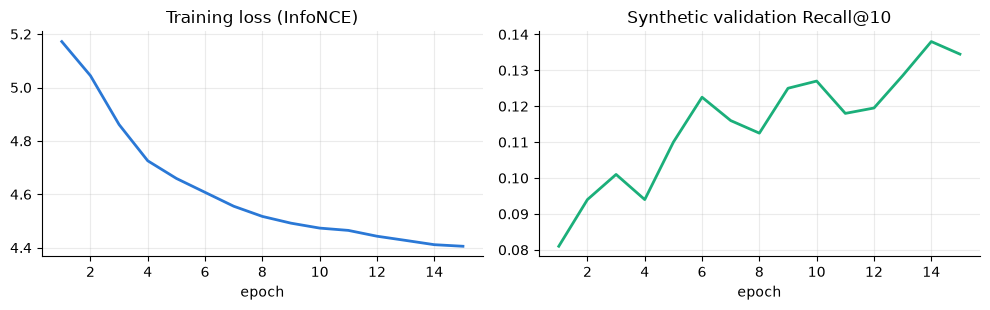

In [22]:
# ---- Synthetic validation metric ----------------------------------------------
@torch.no_grad()
def synthetic_recall_at_k(net, examples, corpus_emb, k=10, batch=512):
    # Recall@k of the fusion module on mined examples, retrieving from the train
    # corpus. Used only for early stopping / model selection (never the benchmark).
    net.eval()
    hits = []
    for i in range(0, len(examples), batch):
        chunk = examples[i:i + batch]
        cond_emb, sign_ids, pad_mask = pad_condition_batch(
            [e["cond_idx"] for e in chunk], [e["signs"] for e in chunk],
            to_device=device,
        )
        src = torch.tensor([e["source"] for e in chunk], dtype=torch.long)
        q = net(corpus_emb[src.to(device)], cond_emb, sign_ids, pad_mask)
        top = rank_topk(q, corpus_emb, src, k)
        for b, e in enumerate(chunk):
            hits.append(int(len(set(top[b].tolist()) & set(e["positives"].tolist())) > 0))
    return float(np.mean(hits))


# ---- Training loop -------------------------------------------------------------
# The model is instantiated HERE (not in the class cell above) so that
# re-running the class definition can never silently replace trained weights:
# this cell always either loads a validated checkpoint or trains.
FUSION_CFG = {"dim": 512, "n_heads": 4, "gate_hidden": 256, "use_self_attn": True}
fusion = GatedCrossAttentionFusion(**FUSION_CFG).to(device)
n_params = sum(p.numel() for p in fusion.parameters())
print(f"Fusion module parameters: {n_params / 1e6:.2f}M (CLIP stays frozen)")

CKPT_PATH = DRIVE_DIR / f"fusion_model{SMOKE_SUFFIX}.pt"
RETRAIN = False          # set True to force retraining even if a checkpoint exists
EPOCHS = 2 if SMOKE_TEST else 15
PATIENCE = 3
TAU = 0.07
LR, WEIGHT_DECAY, BATCH_SIZE, N_HARD = 1e-4, 1e-2, 256, 8

# Stored inside the checkpoint: a checkpoint trained under different
# hyperparameters or different mined data is treated as stale and retrained.
TRAIN_HPARAMS = {
    "tau": TAU, "epochs": EPOCHS, "patience": PATIENCE, "lr": LR,
    "weight_decay": WEIGHT_DECAY, "batch_size": BATCH_SIZE, "n_hard": N_HARD,
    "fusion": FUSION_CFG, "mining": MINING_PARAMS,
}

ckpt = None
if CKPT_PATH.exists() and not RETRAIN:
    ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=False)
    if ckpt.get("hparams") != TRAIN_HPARAMS:
        print("Checkpoint was trained with different hyperparameters — retraining.")
        ckpt = None
if ckpt is not None:
    fusion.load_state_dict(ckpt["state_dict"])
    history = ckpt["history"]
    print(f"Loaded checkpoint (val R@10 = {ckpt['val_r10']:.3f}) from {CKPT_PATH}")
else:
    loader = DataLoader(
        FusionDataset(train_examples, train_emb, n_hard=N_HARD),
        batch_size=BATCH_SIZE, shuffle=True, drop_last=True,
        num_workers=0,  # tensors are already in RAM; workers only add overhead
        collate_fn=collate_fusion,
    )
    opt = torch.optim.AdamW(fusion.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    history = {"loss": [], "val_r10": []}
    best_r10, best_state, bad_epochs = -1.0, None, 0

    for epoch in range(1, EPOCHS + 1):
        fusion.train()
        losses = []
        for batch in tqdm(loader, desc=f"Epoch {epoch}/{EPOCHS}", leave=False):
            batch = {k: v.to(device, non_blocking=True) for k, v in batch.items()}
            q = fusion(batch["v_ref"], batch["cond_emb"],
                       batch["sign_ids"], batch["pad_mask"])
            loss = info_nce_loss(q, batch["v_pos"], batch["v_negs"], TAU)
            opt.zero_grad()
            loss.backward()
            opt.step()
            losses.append(loss.item())

        val_r10 = synthetic_recall_at_k(fusion, val_examples, train_emb_dev)
        history["loss"].append(float(np.mean(losses)))
        history["val_r10"].append(val_r10)
        print(f"epoch {epoch:>2} | loss {history['loss'][-1]:.4f} | val R@10 {val_r10:.3f}")

        if val_r10 > best_r10:
            best_r10, bad_epochs = val_r10, 0
            best_state = {k: v.detach().cpu().clone()
                          for k, v in fusion.state_dict().items()}
        else:
            bad_epochs += 1
            if bad_epochs >= PATIENCE:
                print(f"Early stopping at epoch {epoch}.")
                break

    fusion.load_state_dict(best_state)
    torch.save({"state_dict": best_state, "history": history, "val_r10": best_r10,
                "hparams": TRAIN_HPARAMS}, CKPT_PATH)
    print(f"Best val R@10 = {best_r10:.3f} | checkpoint saved to {CKPT_PATH}")

# Learning curves (two panels, one series each — never a dual-axis chart)
if history["loss"]:
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
    epochs_x = range(1, len(history["loss"]) + 1)
    axes[0].plot(epochs_x, history["loss"], color="#2a78d6", linewidth=2)
    axes[0].set_title("Training loss (InfoNCE)")
    axes[1].plot(epochs_x, history["val_r10"], color="#1baf7a", linewidth=2)
    axes[1].set_title("Synthetic validation Recall@10")
    for ax in axes:
        ax.set_xlabel("epoch")
        ax.grid(alpha=0.25)
        ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()

In [23]:
# ---- Benchmark evaluation of the fusion module --------------------------------
fusion.eval()


def make_queries_fusion(conds, src_idx):
    cond_emb, sign_ids = build_condition_tensors(conds, len(src_idx))
    v = test_emb_dev[src_idx.to(device)]
    return fusion(v, cond_emb, sign_ids, None)  # no padding: same conds for all sources


df_fusion, det_fusion = run_benchmark(
    annotations, make_queries_fusion, "L3 gated cross-attention"
)
df_fusion.round(3)

L3 gated cross-attention:   0%|          | 0/14 [00:00<?, ?it/s]

,method,query,sources,smoke,R@1,P@1,R@5,P@5,R@10,P@10
0,L3 gated cross-attention,+Smiling,4786,False,0.061,0.061,0.167,0.045,0.239,0.037
1,L3 gated cross-attention,+Eyeglasses,2196,False,0.104,0.104,0.347,0.090,0.529,0.085
2,L3 gated cross-attention,-Heavy_Makeup,4087,False,0.039,0.039,0.127,0.029,0.199,0.026
3,L3 gated cross-attention,+Male,1595,False,0.069,0.069,0.207,0.061,0.293,0.057
4,L3 gated cross-attention,-Young,5355,False,0.034,0.034,0.124,0.031,0.198,0.029
5,L3 gated cross-attention,+Blond_Hair,5469,False,0.061,0.061,0.201,0.052,0.296,0.047
6,L3 gated cross-attention,+Mustache,301,False,0.110,0.110,0.316,0.072,0.445,0.059
7,L3 gated cross-attention,-Young,5355,False,0.034,0.034,0.124,0.031,0.198,0.029
8,L3 gated cross-attention,"+Eyeglasses, +Smiling",612,False,0.077,0.077,0.253,0.060,0.410,0.056
9,L3 gated cross-attention,"+Black_Hair, -Wavy_Hair",2572,False,0.037,0.037,0.140,0.031,0.217,0.028


## 8. Results and discussion

All numbers are macro averages over the 14 benchmark queries, evaluated on every
source index in `celeba_evaluation.json` (27,697 source-query pairs) against the
frozen 19,962-image test corpus. Section 10 supplies the controls, ablations and
seed statistics that the claims below rest on.

### 8.1 Headline comparison

| method | R@1 | R@5 | R@10 |
|---|---|---|---|
| C1 text-only (no image) | 0.023 | 0.043 | 0.065 |
| C2 image-only (no text) | 0.019 | 0.053 | 0.076 |
| L1 zero-shot arithmetic | 0.024 | 0.074 | 0.110 |
| L2 visual directions (geodesic) | 0.022 | 0.076 | 0.117 |
| L2 visual directions (linear) | 0.022 | 0.075 | 0.118 |
| **L3 gated cross-attention** | **0.061** | **0.189** | **0.308** |

Two observations that the raw ranking hides:

**The zero-shot baseline is barely above a trivial control.** Returning the
reference image's nearest neighbours while *ignoring the text entirely* (C2)
reaches R@10 = 0.076; latent arithmetic reaches 0.110. The mandatory baseline
therefore buys only ~1.4x over a method that never reads the query. This is the
quantitative form of the compositionality failure discussed in Section 5:
adding a text vector to an image vector moves the query mostly along directions
the corpus does not organise itself by.

**L2 does not justify its machinery.** The geodesic construction (0.117) is
statistically indistinguishable from its own linear ablation (0.118), and both
sit within ~0.01 of L1. Operating in the tangent space with log/exp maps is
theoretically better motivated for a spherical embedding space, but on this task
it changes nothing measurable. We report this as a negative result rather than
omitting it.

### 8.2 How much of the headline is initialisation luck

The deployed checkpoint scores R@10 = 0.308, but it comes from a single
unseeded run. Retraining the identical recipe under five controlled seeds gives

> **R@10 = 0.249 +/- 0.016** (range 0.221-0.261)

so 0.308 is an optimistic draw from the top of the distribution. **Every claim
in this report is therefore stated against the seed mean, not the deployed
number.** Even at 0.249, L3 remains ~2.3x L1 and ~3.3x the image-only control,
so the conclusion that the learned fusion substantially outperforms both
training-free levels is unaffected — only its magnitude changes.

### 8.3 Which components actually earn their place

Section 10.2 removes one mechanism at a time (three seeds each, everything else
fixed). The result contradicts the design narrative of Section 7:

| variant | params | R@10 (mean +/- sd) |
|---|---|---|
| L3 full (reference) | 4.07M | 0.247 +/- 0.022 |
| **- sign embeddings (F3)** | 4.07M | **0.303 +/- 0.008** |
| - cross-attention (F1) | 3.02M | 0.296 +/- 0.007 |
| - gate (F4) | 3.68M | 0.274 +/- 0.025 |
| - self-attention (F2) | 1.97M | 0.227 +/- 0.012 |
| L3-slim (- sign, - cross) | 3.02M | 0.302 +/- 0.017 |

**Learned sign embeddings are actively harmful.** Removing them — reverting to
the Level-1 convention of negating the text embedding for "remove" — improves
R@10 by +0.056, and does so on every individual seed (0.308/0.307/0.293 versus
0.221/0.257/0.261, ranges that never overlap). The motivation in Section 7.1 was
that CLIP handles negation poorly, so the model should *learn* what removal
means; empirically, the free parameters this introduces cost more than the
inductive bias they buy.

**Image-conditioned cross-attention is also counterproductive** (+0.049 to
remove, again non-overlapping ranges). Replacing it with a uniform mean over
condition tokens — which cannot weight conditions by the reference at all — is
better and uses 1.05M fewer parameters. The "dynamic weighting" that motivates
the whole design does not pay off on this benchmark.

**The two effects are redundant, not additive.** Dropping both (L3-slim, 0.302)
is no better than dropping the sign embeddings alone (0.303), which suggests a
single underlying pathology rather than two independent ones — most plausibly
that the extra capacity accelerates the collapse quantified in Section 8.4.

Only self-attention behaves as intended: removing it costs -0.020, the sole
mechanism whose ablation is worse than the reference.

**Recommended final model:** the full architecture *without* learned sign
embeddings, at **R@10 = 0.303 +/- 0.008**. It matches the lucky deployed
checkpoint while being reproducible across seeds, with an sd nearly three times
tighter than the original design. If parameter count matters, `L3-slim - gate`
reaches 0.289 +/- 0.005 with 2.63M parameters (35% fewer).

### 8.4 How L3 wins: retrieval collapse

Recall alone cannot distinguish composed retrieval from returning a fixed set of
broadly-compatible images. We therefore report the fraction of distinct images
appearing in the top-10 across all sources of a query:

| method | distinct top-10 fraction | mean pairwise query cos |
|---|---|---|
| L2 visual directions | 0.761 | 0.602 |
| L1 zero-shot arithmetic | 0.734 | 0.798 |
| **L3 gated cross-attention** | **0.277** | 0.803 |
| C1 text-only (degenerate by construction) | 0.008 | 1.000 |

L3 uses barely a quarter of its retrieval budget on distinct images, against
roughly three quarters for both training-free levels. It has not collapsed to
the text-only degenerate solution — it beats that control 4.7x, and its queries
remain source-dependent — but it is markedly more concentrated, and the
concentration tracks its success: on `+Eyeglasses` (its largest win, 0.529 vs
0.134) only 556 distinct images fill 4,000 slots, whereas on `+Smiling`, where
its retrieval stays diverse (2,360 distinct), it does not beat L1 at all.

The mechanism is visible in the ground-truth definition itself: a valid target
must satisfy the constraints *and* lie within Hamming distance 2 of the source on
the remaining 38 attributes — a condition met most easily by images with common,
modal attribute profiles. L3 appears to have learned to aim at that densely
compatible region rather than tracking each individual reference, which is also
why its composed queries move so far from the source (Section 10.1: up to
1 - cos = 0.93, i.e. nearly orthogonal). This is a legitimate solution to the
benchmark as posed, but it is a weaker claim than "the model composes
attributes", and we state it as such.

### 8.5 Where L3 fails

The one benchmark query L3 loses is
`+Wearing_Lipstick, -Heavy_Makeup, +Smiling` (0.029 vs L1's 0.059) — precisely
the correlated-attribute case predicted to be hardest in Section 7.2, since
lipstick and heavy makeup co-occur strongly in CelebA and the query demands one
without the other. With only 34 sources its CI [0.000, 0.088] overlaps
everything, so this is suggestive rather than conclusive.

More informative is Section 9: on four *custom* queries built with the identical
ground-truth rule, L3 (0.055) falls behind L2 (0.068), and no paired difference
is significant. L3's advantage does not transfer cleanly to query families it was
not trained on.

In [24]:
# ---- Comparative tables --------------------------------------------------------
runs = [df_baseline, df_dirs, df_dirs_lin, df_fusion]

# Refuse to compare runs produced under different SMOKE_TEST modes: a reduced
# 200-source smoke run is not comparable with a full run.
modes = {bool(df["smoke"].iloc[0]) for df in runs}
assert len(modes) == 1, "Benchmark runs mix SMOKE_TEST modes — re-run the benchmark cells"
if modes == {True}:
    # Consistent but reduced: make it impossible to mistake these for real results.
    print("=" * 78)
    print("WARNING: SMOKE_TEST results (max 200 sources per query) — debugging only.")
    print("Set SMOKE_TEST = False and re-run the notebook before reporting numbers:")
    print("the assignment requires evaluating on ALL source indices in the JSON.")
    print("=" * 78)

df_all = pd.concat(runs, ignore_index=True)

print("Macro averages:")
display(
    df_all[df_all["query"] == "MACRO AVERAGE"]
    .set_index("method")[["R@1", "R@5", "R@10", "P@1", "P@5", "P@10"]]
    .round(3)
)

# Per-query Recall@10 (pivot_table because '-Young' appears twice in the benchmark)
per_query = df_all[df_all["query"] != "MACRO AVERAGE"].pivot_table(
    index="query", columns="method", values="R@10", aggfunc="mean"
)
print("Per-query Recall@10:")
display(per_query.round(3))

Macro averages:


,R@1,R@5,R@10,P@1,P@5,P@10
method,,,,,,
L1 zero-shot arithmetic,0.024,0.074,0.110,0.024,0.018,0.015
L2 visual directions,0.022,0.076,0.117,0.022,0.019,0.016
L2 visual directions (linear ablation),0.022,0.075,0.118,0.022,0.019,0.016
L3 gated cross-attention,0.061,0.189,0.308,0.061,0.049,0.045


Per-query Recall@10:


method,L1 zero-shot arithmetic,L2 visual directions,L2 visual directions (linear ablation),L3 gated cross-attention
query,,,,
"+Black_Hair, -Wavy_Hair",0.149,0.108,0.106,0.217
+Blond_Hair,0.132,0.130,0.132,0.296
"+Chubby, -Young",0.024,0.055,0.055,0.397
+Eyeglasses,0.134,0.112,0.111,0.529
"+Eyeglasses, +Smiling",0.095,0.047,0.047,0.410
+Male,0.043,0.164,0.167,0.293
+Mustache,0.236,0.229,0.229,0.445
+Smiling,0.259,0.248,0.248,0.239
"+Wearing_Lipstick, -Heavy_Makeup, +Smiling",0.059,0.088,0.088,0.029


In [25]:
# ---- Statistical soundness: bootstrap confidence intervals ----------------------
# GOAL: Recall@K per query is the mean of a BINARY outcome (hit / no hit) over
# that query's source images. Queries with few sources (27, 34, 79 in this
# benchmark) give noisy estimates, so any claim of the form "method A beats
# method B" needs an uncertainty estimate. We use the bootstrap: resample the
# sources with replacement many times and look at the spread of the statistic.


def bootstrap_ci(hits, n_boot=10000, seed=SEED, chunk=1000):
    # 95% confidence interval for the mean of ONE binary array
    # (one method on one query). Returns (mean, ci_low, ci_high).
    # Replicates are generated in chunks: a full (n_boot, n_sources) int64
    # index matrix would be ~0.4 GB for the largest benchmark queries
    # (5,469 sources x 10,000 replicates); chunking caps the peak at ~40 MB.
    rng = np.random.default_rng(seed)
    n = len(hits)
    means = np.empty(n_boot)
    for start in range(0, n_boot, chunk):
        size = min(chunk, n_boot - start)
        idx = rng.integers(0, n, size=(size, n))
        means[start:start + size] = hits[idx].mean(axis=1)
    return (float(hits.mean()),
            float(np.percentile(means, 2.5)), float(np.percentile(means, 97.5)))


def paired_bootstrap_diff(hits_a, hits_b, n_boot=10000, seed=SEED, chunk=1000):
    # 95% CI for the DIFFERENCE between two methods evaluated on the SAME
    # sources ("paired" test). Each bootstrap replicate resamples the sources
    # ONCE and evaluates both methods on that same resample, so the per-source
    # noise cancels in the difference — the statistically correct way to
    # compare methods that share the evaluation set. If the CI excludes 0,
    # the gap is meaningful at the 5% level; otherwise it may be noise.
    # Chunked for the same memory reason as bootstrap_ci.
    assert len(hits_a) == len(hits_b), "paired test needs the same sources"
    rng = np.random.default_rng(seed)
    n = len(hits_a)
    diffs = np.empty(n_boot)
    for start in range(0, n_boot, chunk):
        size = min(chunk, n_boot - start)
        idx = rng.integers(0, n, size=(size, n))
        diffs[start:start + size] = hits_a[idx].mean(axis=1) - hits_b[idx].mean(axis=1)
    return (float(hits_a.mean() - hits_b.mean()),
            float(np.percentile(diffs, 2.5)), float(np.percentile(diffs, 97.5)))


def unique_entries(details):
    # '-Young' appears twice in the JSON with identical ground truth: keep the
    # first occurrence so no query is double-counted (same rule as the macro).
    seen, out = set(), []
    for d in details:
        if d["query"] not in seen:
            seen.add(d["query"])
            out.append(d)
    return out


def recall_stats(details, k=10, n_boot=5000):
    # Per-query mean Recall@k with its bootstrap CI -> {query: (mean, lo, hi)}.
    return {d["query"]: bootstrap_ci(d["recall_hits"][k], n_boot=n_boot)
            for d in unique_entries(details)}


def paired_report(det_a, det_b, k=10):
    # Per-query difference in Recall@k between two methods, with the paired
    # bootstrap CI and a significance flag (CI excludes zero).
    rows = []
    for da, db in zip(unique_entries(det_a), unique_entries(det_b)):
        assert np.array_equal(da["sources"], db["sources"]), \
            "methods must be evaluated on the same sources to be paired"
        diff, lo, hi = paired_bootstrap_diff(da["recall_hits"][k],
                                             db["recall_hits"][k])
        rows.append({"query": da["query"], "diff": diff,
                     "CI lo": lo, "CI hi": hi,
                     "significant": bool(lo > 0 or hi < 0)})
    return pd.DataFrame(rows)


# ---- Per-query table with CIs (primary metric, R@10) -----------------------------
main_methods = {
    "L1 zero-shot arithmetic": det_baseline,
    "L2 visual directions": det_dirs,
    "L3 gated cross-attention": det_fusion,
}
ci_table = pd.DataFrame({
    m: {q: f"{mean:.3f} [{lo:.3f}, {hi:.3f}]"
        for q, (mean, lo, hi) in recall_stats(det, 10).items()}
    for m, det in main_methods.items()
})
print("Recall@10 per query, mean [95% bootstrap CI]:")
display(ci_table)

# ---- Paired comparisons: is each gap real or noise? -------------------------------
for name_a, name_b in [("L3 gated cross-attention", "L2 visual directions"),
                       ("L3 gated cross-attention", "L1 zero-shot arithmetic"),
                       ("L2 visual directions", "L1 zero-shot arithmetic")]:
    rep = paired_report(main_methods[name_a], main_methods[name_b])
    n_sig = int(rep["significant"].sum())
    print(f"\n{name_a}  vs  {name_b} — delta R@10 per query "
          f"({n_sig}/{len(rep)} significant at 95%):")
    display(rep.round(3))

Recall@10 per query, mean [95% bootstrap CI]:


,L1 zero-shot arithmetic,L2 visual directions,L3 gated cross-attention
+Smiling,"0.259 [0.246, 0.271]","0.248 [0.235, 0.260]","0.239 [0.227, 0.251]"
+Eyeglasses,"0.134 [0.121, 0.149]","0.112 [0.099, 0.125]","0.529 [0.508, 0.550]"
-Heavy_Makeup,"0.149 [0.138, 0.160]","0.158 [0.147, 0.169]","0.199 [0.187, 0.211]"
+Male,"0.043 [0.033, 0.053]","0.164 [0.147, 0.182]","0.293 [0.270, 0.317]"
-Young,"0.056 [0.050, 0.062]","0.075 [0.068, 0.082]","0.198 [0.187, 0.208]"
+Blond_Hair,"0.132 [0.123, 0.141]","0.130 [0.121, 0.139]","0.296 [0.284, 0.308]"
+Mustache,"0.236 [0.186, 0.286]","0.229 [0.183, 0.279]","0.445 [0.389, 0.502]"
"+Eyeglasses, +Smiling","0.095 [0.072, 0.119]","0.047 [0.031, 0.065]","0.410 [0.371, 0.449]"
"+Black_Hair, -Wavy_Hair","0.149 [0.135, 0.163]","0.108 [0.096, 0.120]","0.217 [0.201, 0.233]"
"-Male, -Mustache","0.000 [0.000, 0.000]","0.074 [0.000, 0.185]","0.259 [0.111, 0.444]"



L3 gated cross-attention  vs  L2 visual directions — delta R@10 per query (10/13 significant at 95%):


,query,diff,CI lo,CI hi,significant
0,+Smiling,-0.009,-0.019,0.001,False
1,+Eyeglasses,0.418,0.395,0.440,True
2,-Heavy_Makeup,0.041,0.029,0.053,True
3,+Male,0.129,0.104,0.154,True
4,-Young,0.123,0.112,0.134,True
5,+Blond_Hair,0.165,0.153,0.178,True
6,+Mustache,0.216,0.156,0.276,True
7,"+Eyeglasses, +Smiling",0.363,0.324,0.402,True
8,"+Black_Hair, -Wavy_Hair",0.109,0.094,0.126,True
9,"-Male, -Mustache",0.185,0.000,0.370,False



L3 gated cross-attention  vs  L1 zero-shot arithmetic — delta R@10 per query (12/13 significant at 95%):


,query,diff,CI lo,CI hi,significant
0,+Smiling,-0.020,-0.030,-0.009,True
1,+Eyeglasses,0.395,0.372,0.417,True
2,-Heavy_Makeup,0.050,0.038,0.063,True
3,+Male,0.251,0.228,0.275,True
4,-Young,0.141,0.130,0.153,True
5,+Blond_Hair,0.164,0.151,0.176,True
6,+Mustache,0.209,0.150,0.272,True
7,"+Eyeglasses, +Smiling",0.315,0.278,0.353,True
8,"+Black_Hair, -Wavy_Hair",0.068,0.052,0.085,True
9,"-Male, -Mustache",0.259,0.111,0.444,True



L2 visual directions  vs  L1 zero-shot arithmetic — delta R@10 per query (8/13 significant at 95%):


,query,diff,CI lo,CI hi,significant
0,+Smiling,-0.011,-0.018,-0.004,True
1,+Eyeglasses,-0.023,-0.032,-0.014,True
2,-Heavy_Makeup,0.010,0.001,0.018,True
3,+Male,0.122,0.105,0.139,True
4,-Young,0.018,0.013,0.024,True
5,+Blond_Hair,-0.002,-0.008,0.004,False
6,+Mustache,-0.007,-0.033,0.020,False
7,"+Eyeglasses, +Smiling",-0.047,-0.067,-0.028,True
8,"+Black_Hair, -Wavy_Hair",-0.041,-0.051,-0.031,True
9,"-Male, -Mustache",0.074,0.000,0.185,False


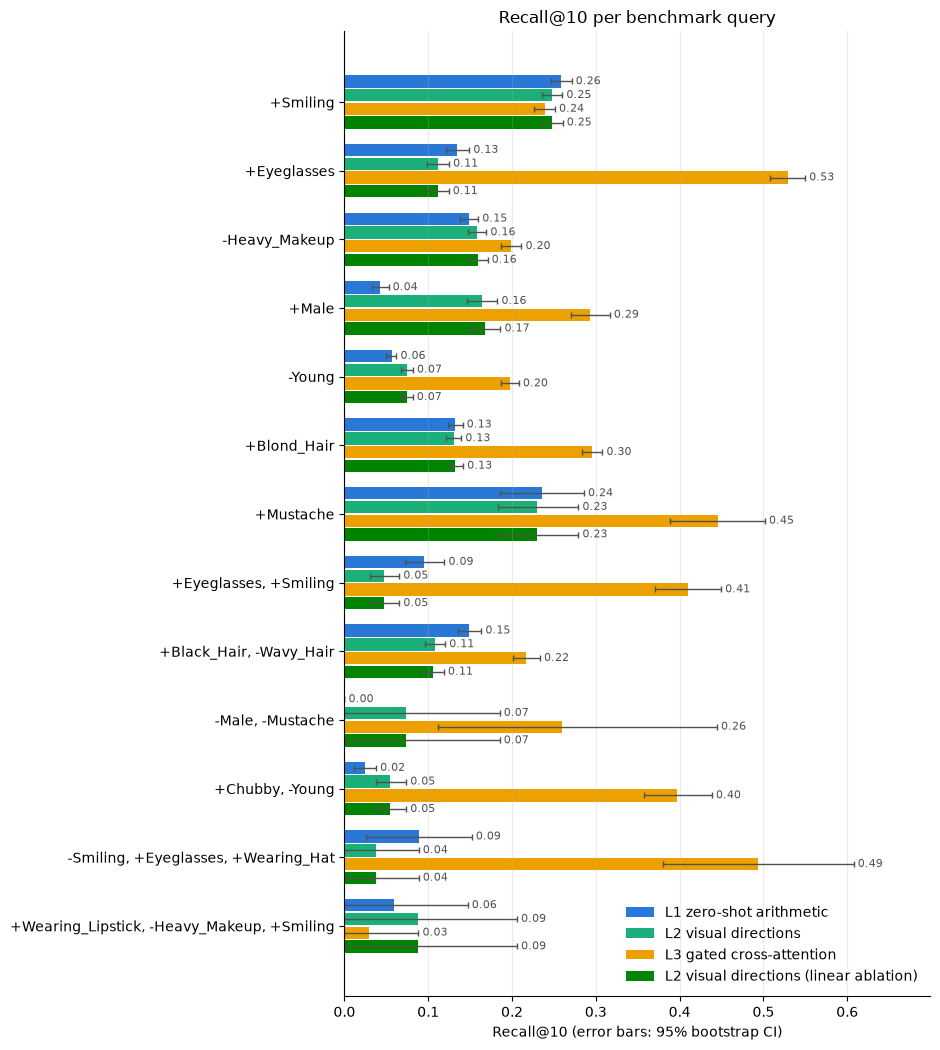

In [26]:
# ---- Per-query Recall@10 chart with 95% bootstrap error bars ---------------------
# The error bars visualize the CIs computed above: overlapping bars on
# small-source queries mean the difference there should not be over-claimed.
chart_details = {
    "L1 zero-shot arithmetic": det_baseline,
    "L2 visual directions": det_dirs,
    "L3 gated cross-attention": det_fusion,
    "L2 visual directions (linear ablation)": det_dirs_lin,
}
chart_stats = {m: recall_stats(d, k=10) for m, d in chart_details.items()}

methods = [m for m in METHOD_COLORS if m in chart_stats]  # fixed order = fixed colors
queries = list(next(iter(chart_stats.values())).keys())   # unique, benchmark order
y = np.arange(len(queries))
bar_h = 0.8 / max(len(methods), 1)

fig, ax = plt.subplots(figsize=(9.5, 0.7 * len(queries) + 1.5))
for j, m in enumerate(methods):
    means = np.array([chart_stats[m][q][0] for q in queries])
    ci_lo = np.array([chart_stats[m][q][1] for q in queries])
    ci_hi = np.array([chart_stats[m][q][2] for q in queries])
    offset = (j - (len(methods) - 1) / 2) * bar_h
    bars = ax.barh(y + offset, means, height=bar_h * 0.9,
                   xerr=[means - ci_lo, ci_hi - means], capsize=2,
                   error_kw={"ecolor": "#52514e", "elinewidth": 1},
                   color=METHOD_COLORS[m], label=m)
    ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=8, color="#52514e")

ax.set_yticks(y, queries)
ax.invert_yaxis()
ax.set_xlabel("Recall@10 (error bars: 95% bootstrap CI)")
max_hi = max(chart_stats[m][q][2] for m in methods for q in queries)
ax.set_xlim(0, min(1.0, max_hi * 1.15))
ax.grid(axis="x", alpha=0.25)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(loc="lower right", frameon=False)
ax.set_title("Recall@10 per benchmark query")
plt.tight_layout()
plt.show()

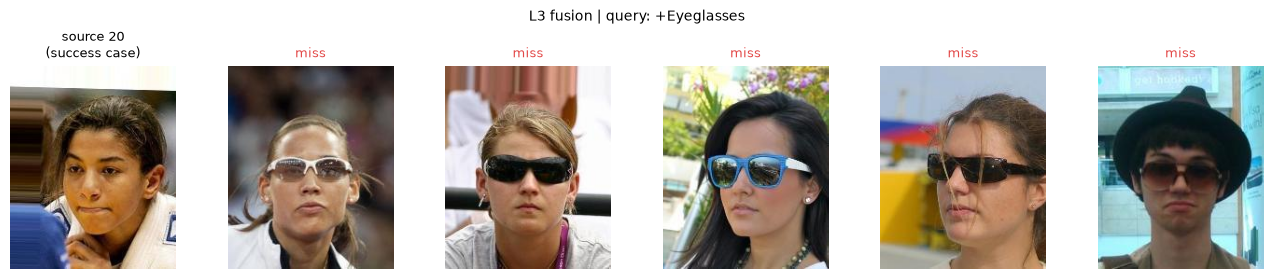

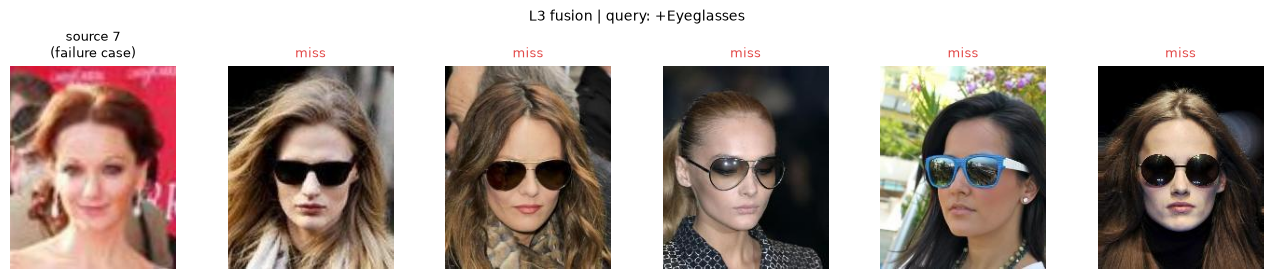

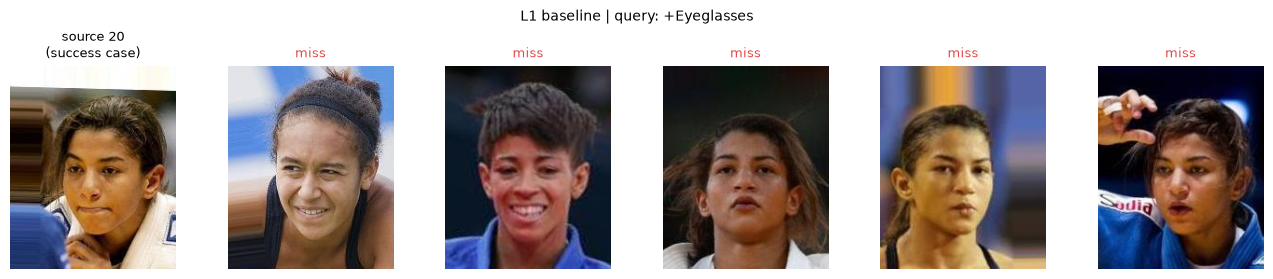

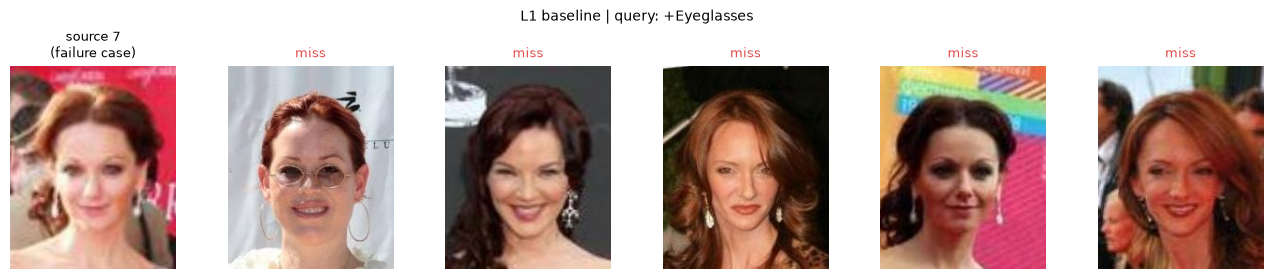

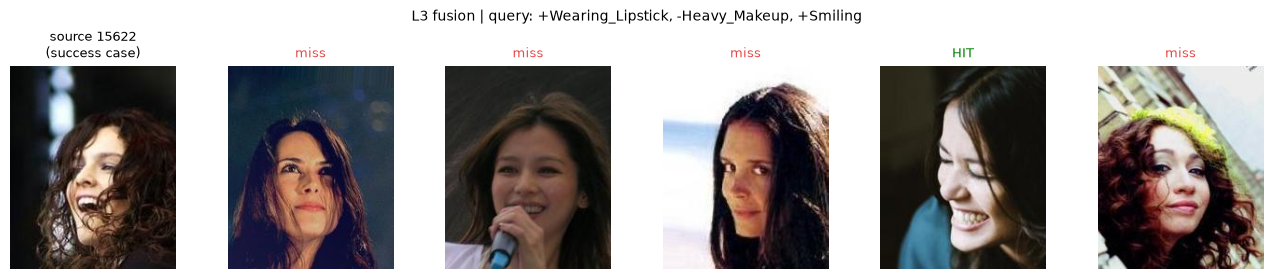

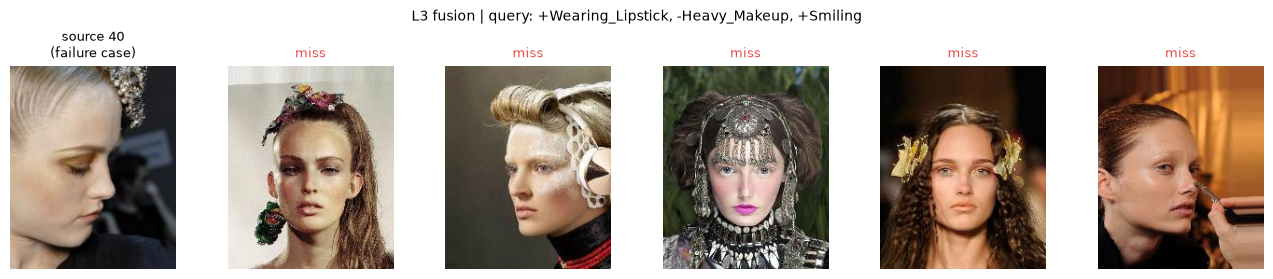

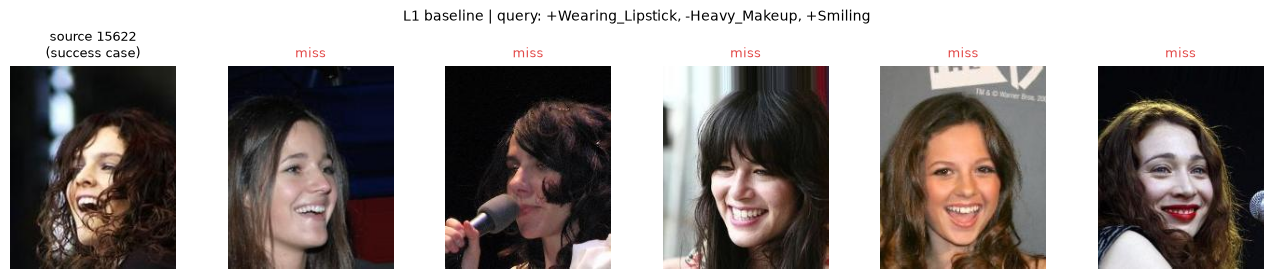

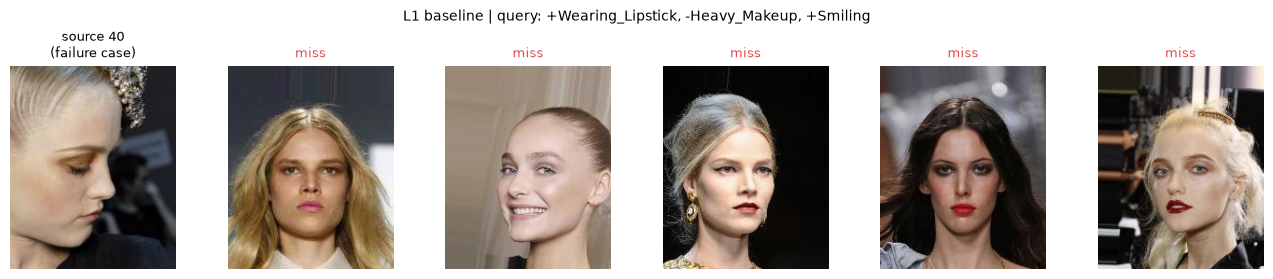

In [27]:
# ---- Qualitative examples: explicit SUCCESS and FAILURE cases --------------------
# The assignment requires qualitative examples of both successes AND failures.
# Instead of sampling sources at random (which could show only successes for a
# good method), we pick, for each query, one source the fusion model solved
# (>= 1 valid target in the top-10) and one it did not — and show the SAME two
# sources for the baseline, so the visual comparison is apples-to-apples.
@torch.no_grad()
def show_retrieval(entry, make_queries, method_name, labelled_sources, n_top=5):
    # labelled_sources: list of (source_idx, label) pairs, e.g. the output of
    # pick_success_and_failure() below.
    conds = parse_query(entry["query"])
    for s, label in labelled_sources:
        Q = make_queries(conds, torch.tensor([s]))
        top = rank_topk(Q, test_emb_dev, torch.tensor([s]), n_top)[0].tolist()
        gt_set = set(entry["ground_truth"][str(s)])

        fig, axes = plt.subplots(1, n_top + 1, figsize=(2.2 * (n_top + 1), 2.8))
        axes[0].imshow(celeba_test[s][0])
        axes[0].set_title(f"source {s}\n({label})", fontsize=9)
        for j, t in enumerate(top):
            axes[j + 1].imshow(celeba_test[t][0])
            hit = t in gt_set
            axes[j + 1].set_title("HIT" if hit else "miss", fontsize=9,
                                  color="#008300" if hit else "#e34948")
        for ax in axes:
            ax.axis("off")
        fig.suptitle(f"{method_name} | query: {entry['query']}", fontsize=10)
        plt.tight_layout()
        plt.show()


def pick_success_and_failure(entry_idx, details, k=10):
    # Picks one solved and one unsolved source for the given benchmark entry,
    # based on the per-source outcomes stored by run_benchmark. Labels refer
    # to the method whose `details` are passed in (here: the fusion model).
    d = details[entry_idx]
    hits, src = d["recall_hits"][k], d["sources"]
    picked = []
    if hits.any():
        picked.append((int(src[np.flatnonzero(hits == 1)[0]]), "success case"))
    if (hits == 0).any():
        picked.append((int(src[np.flatnonzero(hits == 0)[0]]), "failure case"))
    return picked


# One simple and one composed query; change the indices to explore others.
for entry_idx in (1, len(annotations) - 1):
    labelled = pick_success_and_failure(entry_idx, det_fusion)
    show_retrieval(annotations[entry_idx], make_queries_fusion, "L3 fusion", labelled)
    show_retrieval(annotations[entry_idx], make_queries_baseline, "L1 baseline", labelled)

+Eyeglasses, +Smiling                         movement (1 - cos): 0.800 | mean gate opening: 0.367
+Black_Hair, -Wavy_Hair                       movement (1 - cos): 0.648 | mean gate opening: 0.222
-Male, -Mustache                              movement (1 - cos): 0.931 | mean gate opening: 0.304
+Chubby, -Young                               movement (1 - cos): 0.813 | mean gate opening: 0.326
-Smiling, +Eyeglasses, +Wearing_Hat           movement (1 - cos): 0.855 | mean gate opening: 0.350
+Wearing_Lipstick, -Heavy_Makeup, +Smiling    movement (1 - cos): 0.583 | mean gate opening: 0.232


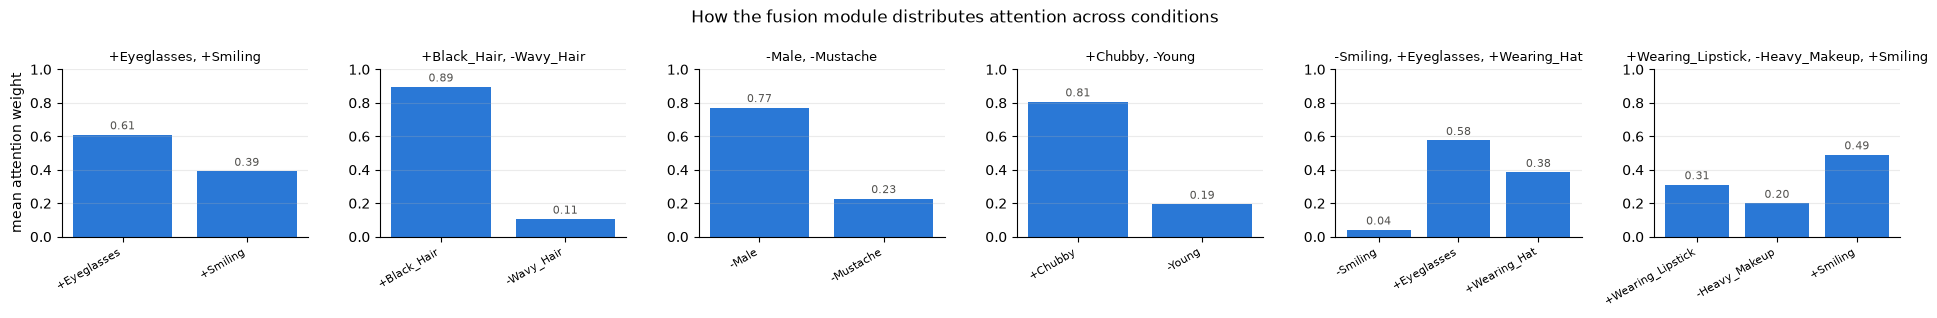

In [28]:
# ---- Interpretability: attention weights and gate behavior -----------------------
@torch.no_grad()
def attention_report(entry, max_sources=256):
    # Mean cross-attention weight per condition + how far the query moved from
    # the reference (1 - cosine), aggregated over the query's source images.
    conds = parse_query(entry["query"])
    src = torch.tensor([int(s) for s in entry["ground_truth"].keys()][:max_sources])
    cond_emb, sign_ids = build_condition_tensors(conds, len(src))
    v = test_emb_dev[src.to(device)]
    q, attn, g = fusion(v, cond_emb, sign_ids, None, return_attn=True)
    movement = 1 - (q * v).sum(dim=-1)          # how far the query moved
    gate_mag = g.mean(dim=-1)                   # average gate opening per source
    return conds, attn.cpu().numpy(), movement.cpu().numpy(), gate_mag.cpu().numpy()


composed = [e for e in annotations if len(parse_query(e["query"])) >= 2]
fig, axes = plt.subplots(1, len(composed), figsize=(3.2 * len(composed), 3.2), squeeze=False)
for ax, entry in zip(axes[0], composed):
    conds, attn, movement, gate_mag = attention_report(entry)
    labels = [("+" if s > 0 else "-") + a for a, s in conds]
    bars = ax.bar(range(len(conds)), attn.mean(axis=0), color="#2a78d6")
    ax.bar_label(bars, fmt="%.2f", padding=2, fontsize=8, color="#52514e")
    ax.set_xticks(range(len(conds)), labels, rotation=30, ha="right", fontsize=8)
    ax.set_ylim(0, 1)
    ax.grid(axis="y", alpha=0.25)
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_title(entry["query"], fontsize=9)
    print(f"{entry['query']:<45} movement (1 - cos): {movement.mean():.3f}"
          f" | mean gate opening: {gate_mag.mean():.3f}")
axes[0][0].set_ylabel("mean attention weight")
fig.suptitle("How the fusion module distributes attention across conditions")
plt.tight_layout()
plt.show()

## 9. Custom queries — beyond the mandatory benchmark

The assignment strongly encourages evaluating on additional custom queries. We
**pre-registered four**, each testing one specific hypothesis about the system —
chosen *before* looking at any result, and all reported regardless of outcome:

| Query | Hypothesis |
|---|---|
| `+Heavy_Makeup, -Wearing_Lipstick` | **H1 — correlated conflict**: makeup and lipstick are strongly correlated in CelebA; can the fusion add one while removing the other, against the dataset bias? |
| `+Male, +Wearing_Lipstick` | **H2 — out-of-distribution combination**: nearly absent in the corpus. If the official rule cannot even build ground truth for it, that is itself a dataset-bias finding worth reporting |
| `-Smiling, +Eyeglasses, +Male, -Young` | **H3 — four conditions**: the benchmark stops at 3 and training mined $k \le 3$; does the module extrapolate to longer queries? |
| `+Bangs, -Black_Hair` | **H4 — outside the mining bias**: 70% of mined training conditions used benchmark attributes; how much do unseen attributes cost? |

**Methodological rules**: the ground truth is built with *exactly* the official rule
(targets satisfy every condition and are within Hamming distance ≤ 2 of the source;
sources need ≥ 5 valid targets and must not already satisfy the conditions). Queries
that yield too few sources are reported as such, and the bootstrap CIs from §8
quantify the resulting uncertainty. These queries were never used for any tuning.

In [29]:
# ---- Building custom benchmark entries with the OFFICIAL rule --------------------
# GOAL: extend the evaluation beyond the mandatory queries while staying 100%
# comparable with it — same ground-truth construction, same metrics, same
# pipeline (run_benchmark). Only the query strings are new.
attrs_test_dev = attrs_test.to(device)


def build_custom_entry(query_str, max_sources=500, seed=SEED):
    # Replicates the construction of celeba_evaluation.json for a new query:
    #   TARGET valid <=> satisfies every +/- condition AND its remaining
    #                    attributes are within Hamming distance <= 2 of the
    #                    source (identity preserved);
    #   SOURCE valid <=> has the OPPOSITE value of every condition (it must not
    #                    already satisfy the query — the convention measured by
    #                    the sanity check in §4) AND has >= 5 valid targets
    #                    (the benchmark's own statistical-significance filter).
    conds = parse_query(query_str)
    cond_idx = torch.tensor([attribute2idx[a] for a, _ in conds], device=device)
    tgt_vals = torch.tensor([1 if s > 0 else 0 for _, s in conds],
                            dtype=attrs_test_dev.dtype, device=device)

    satisfies = (attrs_test_dev[:, cond_idx] == tgt_vals).all(dim=1)
    src_candidates = (attrs_test_dev[:, cond_idx] == 1 - tgt_vals).all(dim=1)
    other = torch.ones(N_ATTRS, dtype=torch.bool, device=device)
    other[cond_idx] = False

    candidates = src_candidates.nonzero(as_tuple=True)[0].cpu().numpy()
    np.random.default_rng(seed).shuffle(candidates)  # unbiased source subset

    gt = {}
    for s in candidates:
        s = int(s)
        ham = (attrs_test_dev[:, other] != attrs_test_dev[s, other]).sum(dim=1)
        valid = satisfies & (ham <= 2)
        valid[s] = False
        idx = valid.nonzero(as_tuple=True)[0]
        if len(idx) >= 5:                 # same filter as the official benchmark
            gt[str(s)] = idx.cpu().tolist()
        if len(gt) >= max_sources:        # cap for evaluation speed
            break
    return {"query": query_str, "ground_truth": gt}


CUSTOM_QUERIES = [
    "+Heavy_Makeup, -Wearing_Lipstick",       # H1: correlated-attribute conflict
    "+Male, +Wearing_Lipstick",               # H2: out-of-distribution combination
    "-Smiling, +Eyeglasses, +Male, -Young",   # H3: four conditions (> training k)
    "+Bangs, -Black_Hair",                    # H4: attributes outside mining bias
]

custom_annotations = []
for q in CUSTOM_QUERIES:
    entry = build_custom_entry(q)
    n = len(entry["ground_truth"])
    status = "OK" if n >= 10 else "few/no sources -> dataset-bias finding"
    print(f"{q:<42} sources: {n:>4}  [{status}]")
    if n > 0:
        custom_annotations.append(entry)

+Heavy_Makeup, -Wearing_Lipstick           sources:  244  [OK]


+Male, +Wearing_Lipstick                   sources:   25  [OK]


-Smiling, +Eyeglasses, +Male, -Young       sources:   90  [OK]


+Bangs, -Black_Hair                        sources:  500  [OK]


In [30]:
# ---- Evaluating the three methods on the custom queries --------------------------
# Same pipeline as the official benchmark; results are directly comparable.
if not custom_annotations:
    print("No custom query produced enough sources — report this as a corpus "
          "sparsity finding in the discussion.")
else:
    df_c1, det_c1 = run_benchmark(custom_annotations, make_queries_baseline,
                                  "L1 zero-shot arithmetic")
    df_c2, det_c2 = run_benchmark(custom_annotations, make_queries_dirs_geodesic,
                                  "L2 visual directions")
    df_c3, det_c3 = run_benchmark(custom_annotations, make_queries_fusion,
                                  "L3 gated cross-attention")

    print("Custom queries — full metric table:")
    display(pd.concat([df_c1, df_c2, df_c3], ignore_index=True).round(3))

    # CIs matter even more here: custom queries can have few sources.
    print("Custom queries — Recall@10, mean [95% bootstrap CI]:")
    display(pd.DataFrame({
        m: {q: f"{mean:.3f} [{lo:.3f}, {hi:.3f}]"
            for q, (mean, lo, hi) in recall_stats(det, 10).items()}
        for m, det in [("L1 zero-shot arithmetic", det_c1),
                       ("L2 visual directions", det_c2),
                       ("L3 gated cross-attention", det_c3)]
    }))

    print("Paired L3 vs L2 on the custom queries:")
    display(paired_report(det_c3, det_c2).round(3))

L1 zero-shot arithmetic:   0%|          | 0/4 [00:00<?, ?it/s]

L2 visual directions:   0%|          | 0/4 [00:00<?, ?it/s]

L3 gated cross-attention:   0%|          | 0/4 [00:00<?, ?it/s]

Custom queries — full metric table:


,method,query,sources,smoke,R@1,P@1,R@5,P@5,R@10,P@10
0,L1 zero-shot arithmetic,"+Heavy_Makeup, -Wearing_Lipstick",244,False,0.004,0.004,0.025,0.006,0.037,0.004
1,L1 zero-shot arithmetic,"+Male, +Wearing_Lipstick",25,False,0.000,0.000,0.000,0.000,0.000,0.000
2,L1 zero-shot arithmetic,"-Smiling, +Eyeglasses, +Male, -Young",90,False,0.000,0.000,0.000,0.000,0.000,0.000
3,L1 zero-shot arithmetic,"+Bangs, -Black_Hair",500,False,0.020,0.020,0.090,0.020,0.114,0.016
4,L1 zero-shot arithmetic,MACRO AVERAGE,859,False,0.006,0.006,0.029,0.007,0.038,0.005
5,L2 visual directions,"+Heavy_Makeup, -Wearing_Lipstick",244,False,0.004,0.004,0.016,0.004,0.041,0.005
6,L2 visual directions,"+Male, +Wearing_Lipstick",25,False,0.000,0.000,0.000,0.000,0.000,0.000
7,L2 visual directions,"-Smiling, +Eyeglasses, +Male, -Young",90,False,0.022,0.022,0.078,0.016,0.133,0.014
8,L2 visual directions,"+Bangs, -Black_Hair",500,False,0.016,0.016,0.058,0.014,0.098,0.013
9,L2 visual directions,MACRO AVERAGE,859,False,0.011,0.011,0.038,0.009,0.068,0.008


Custom queries — Recall@10, mean [95% bootstrap CI]:


,L1 zero-shot arithmetic,L2 visual directions,L3 gated cross-attention
"+Heavy_Makeup, -Wearing_Lipstick","0.037 [0.016, 0.061]","0.041 [0.016, 0.066]","0.029 [0.008, 0.053]"
"+Male, +Wearing_Lipstick","0.000 [0.000, 0.000]","0.000 [0.000, 0.000]","0.000 [0.000, 0.000]"
"-Smiling, +Eyeglasses, +Male, -Young","0.000 [0.000, 0.000]","0.133 [0.067, 0.211]","0.078 [0.022, 0.133]"
"+Bangs, -Black_Hair","0.114 [0.086, 0.144]","0.098 [0.072, 0.126]","0.114 [0.086, 0.142]"


Paired L3 vs L2 on the custom queries:


,query,diff,CI lo,CI hi,significant
0,"+Heavy_Makeup, -Wearing_Lipstick",-0.012,-0.041,0.012,False
1,"+Male, +Wearing_Lipstick",0.000,0.000,0.000,False
2,"-Smiling, +Eyeglasses, +Male, -Young",-0.056,-0.144,0.022,False
3,"+Bangs, -Black_Hair",0.016,-0.010,0.042,False


## 10. Controls, ablations and robustness

Three questions the headline number alone cannot answer:

1. **Is the fusion module really using both modalities?** Two controls bound the
   problem from below: `TEXT-ONLY` ignores the reference image, `IMAGE-ONLY`
   ignores the text. Any method worth reporting must beat both.
2. **Does each architectural component earn its place?** Section 7.1 motivates four
   mechanisms (sign embeddings, self-attention, cross-attention, gate) by the
   failure modes F1-F4. Here each one is removed in turn, everything else fixed.
3. **Is the gain robust?** We retrain across seeds, and — because mining is
   deliberately biased toward the benchmark's own attributes — we retrain once
   with *unbiased* sampling to separate genuine composition from distribution
   fitting.

We also report **retrieval diversity**: the number of distinct images appearing
in the top-10 across all sources of a query. A method that returns nearly the
same images regardless of the reference is not doing composed retrieval, even
if its recall is high.

In [31]:
# ---- 10.1 Single-modality controls + retrieval diversity --------------------
import torch.nn.functional as _F


def make_queries_textonly(conds, src_idx):
    # Ignores the reference image entirely: pure text-to-image retrieval.
    t = torch.stack([sign * text_feats[attribute2idx[a]] for a, sign in conds]).sum(dim=0)
    return _F.normalize(t, dim=-1).unsqueeze(0).expand(len(src_idx), -1).contiguous()


def make_queries_imageonly(conds, src_idx):
    # Ignores the text entirely: returns the reference's nearest neighbours.
    return _F.normalize(test_emb_dev[src_idx.to(device)], dim=-1)


df_txt, det_txt = run_benchmark(annotations, make_queries_textonly, "C1 text-only (no image)")
df_img, det_img = run_benchmark(annotations, make_queries_imageonly, "C2 image-only (no text)")


@torch.no_grad()
def diversity(make_queries, entry, cap=400, k=10):
    # Distinct images in the top-k across sources, plus mean pairwise cosine of
    # the composed queries. Collapse -> few distinct images, cosine -> 1.
    conds = parse_query(entry["query"])
    src = torch.tensor([int(s) for s in entry["ground_truth"].keys()][:cap], dtype=torch.long)
    Q = _F.normalize(make_queries(conds, src).detach(), dim=-1)
    n = len(Q)
    P = Q @ Q.T
    mean_cos = float((P.sum() - torch.diagonal(P).sum()) / (n * n - n))
    uniq = int(torch.unique(rank_topk(Q, test_emb_dev, src, k)).numel())
    return {"sources": n, "distinct@10": uniq, "max": n * k,
            "frac_distinct": uniq / (n * k), "mean_pair_cos": mean_cos}


METHODS_FOR_DIV = [("L1", make_queries_baseline),
                   ("L2", make_queries_dirs_geodesic),
                   ("L3", make_queries_fusion),
                   ("C1 text-only", make_queries_textonly)]

div_rows = []
for entry in annotations:
    for name, fn in METHODS_FOR_DIV:
        div_rows.append({"query": entry["query"], "method": name, **diversity(fn, entry)})
df_div = pd.DataFrame(div_rows)

print("Controls vs the three levels (macro averages):")
display(pd.concat([df_baseline, df_dirs, df_fusion, df_txt, df_img],
                  ignore_index=True)
        .query("query == 'MACRO AVERAGE'")[["method", "R@1", "R@5", "R@10"]]
        .round(3).reset_index(drop=True))

print("\nRetrieval diversity — mean fraction of distinct images in top-10:")
display(df_div.groupby("method")[["frac_distinct", "mean_pair_cos"]].mean().round(3))

C1 text-only (no image):   0%|          | 0/14 [00:00<?, ?it/s]

C2 image-only (no text):   0%|          | 0/14 [00:00<?, ?it/s]

Controls vs the three levels (macro averages):


,method,R@1,R@5,R@10
0,L1 zero-shot arithmetic,0.024,0.074,0.110
1,L2 visual directions,0.022,0.076,0.117
2,L3 gated cross-attention,0.061,0.189,0.308
3,C1 text-only (no image),0.023,0.043,0.065
4,C2 image-only (no text),0.019,0.053,0.076



Retrieval diversity — mean fraction of distinct images in top-10:


,frac_distinct,mean_pair_cos
method,,
C1 text-only,0.008,1.000
L1,0.734,0.798
L2,0.761,0.602
L3,0.277,0.803


In [32]:
# ---- 10.2 Component ablations ------------------------------------------------
# Each variant removes exactly one mechanism; everything else (data, optimizer,
# epochs, seed) is held fixed, so any difference is attributable to that part.

def train_variant(cfg, train_ex, val_ex, seed=SEED, epochs=EPOCHS, tag=""):
    # Trains one fusion variant from scratch and returns (net, best_val_r10).
    torch.manual_seed(seed)
    np.random.seed(seed)
    net = GatedCrossAttentionFusion(**cfg).to(device)
    loader = DataLoader(FusionDataset(train_ex, train_emb, n_hard=N_HARD),
                        batch_size=BATCH_SIZE, shuffle=True, drop_last=True,
                        num_workers=0, collate_fn=collate_fusion)
    opt = torch.optim.AdamW(net.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    best, best_state, bad = -1.0, None, 0
    for epoch in range(1, epochs + 1):
        net.train()
        for batch in loader:
            batch = {k: v.to(device, non_blocking=True) for k, v in batch.items()}
            loss = info_nce_loss(net(batch["v_ref"], batch["cond_emb"],
                                     batch["sign_ids"], batch["pad_mask"]),
                                 batch["v_pos"], batch["v_negs"], TAU)
            opt.zero_grad(); loss.backward(); opt.step()
        v = synthetic_recall_at_k(net, val_ex, train_emb_dev)
        if v > best:
            best, bad = v, 0
            best_state = {k: t.detach().cpu().clone() for k, t in net.state_dict().items()}
        else:
            bad += 1
            if bad >= PATIENCE:
                break
    net.load_state_dict(best_state)
    net.eval()
    return net, best


def bench_net(net, name, anns=None):
    def mk(conds, src_idx):
        cond_emb, sign_ids = build_condition_tensors(conds, len(src_idx))
        return net(test_emb_dev[src_idx.to(device)], cond_emb, sign_ids, None)
    return run_benchmark(anns if anns is not None else annotations, mk, name)


ABLATIONS = [
    ("L3 full (reference)",        dict(FUSION_CFG)),
    ("- sign embeddings (F3)",     {**FUSION_CFG, "use_sign_emb": False}),
    ("- self-attention (F2)",      {**FUSION_CFG, "use_self_attn": False}),
    ("- cross-attention (F1)",     {**FUSION_CFG, "use_cross_attn": False}),
    ("- gate (F4)",                {**FUSION_CFG, "use_gate": False}),
    # Combined variants: the single-mechanism ablations above show that the
    # sign embeddings and the cross-attention each HURT. If those effects are
    # real and roughly additive, dropping both should beat every variant above
    # — a prediction the next two rows test directly.
    ("L3-slim (- sign, - cross)",  {**FUSION_CFG, "use_sign_emb": False,
                                    "use_cross_attn": False}),
    ("L3-slim - gate",             {**FUSION_CFG, "use_sign_emb": False,
                                    "use_cross_attn": False, "use_gate": False}),
]

ABL_SEEDS = [SEED, SEED + 1, SEED + 2]
ABL_PATH = DRIVE_DIR / f"ablations{SMOKE_SUFFIX}.pt"
ABL_KEY = {"cfgs": [c for _, c in ABLATIONS], "hparams": TRAIN_HPARAMS,
           "seeds": ABL_SEEDS, "v": 2}
abl_cache = None
if ABL_PATH.exists():
    abl_cache = torch.load(ABL_PATH, map_location="cpu", weights_only=False)
    if abl_cache.get("key") != ABL_KEY:
        print("Ablation cache is stale — recomputing.")
        abl_cache = None

if abl_cache is None:
    abl_rows = []
    for name, cfg in ABLATIONS:
        for sd in tqdm(ABL_SEEDS, desc=name):
            net, val = train_variant(cfg, train_examples, val_examples, seed=sd)
            df, _ = bench_net(net, name)
            m = df[df["query"] == "MACRO AVERAGE"].iloc[0]
            abl_rows.append({"variant": name, "seed": sd,
                             "val R@10": round(val, 3),
                             "R@1": m["R@1"], "R@5": m["R@5"], "R@10": m["R@10"],
                             "params (M)": round(sum(p.numel() for p in net.parameters()) / 1e6, 2)})
    df_abl_raw = pd.DataFrame(abl_rows)
    torch.save({"key": ABL_KEY, "df": df_abl_raw}, ABL_PATH)
else:
    df_abl_raw = abl_cache["df"]
    print("Loaded cached ablation results.")

# Mean +/- sd across seeds: single-seed ablations are not separable from
# initialisation noise (the seed study in 10.3 measures that noise directly).
df_abl = (df_abl_raw.groupby("variant", sort=False)
          .agg(**{"params (M)": ("params (M)", "first"),
                  "R@1": ("R@1", "mean"),
                  "R@5": ("R@5", "mean"),
                  "R@10 mean": ("R@10", "mean"),
                  "R@10 sd": ("R@10", "std")})
          .reset_index())

print(f"Component ablations — benchmark macro, mean over {len(ABL_SEEDS)} seeds:")
display(df_abl.round(3))
print("\nPer-seed detail:")
display(df_abl_raw.round(3))

Loaded cached ablation results.
Component ablations — benchmark macro, mean over 3 seeds:


,variant,params (M),R@1,R@5,R@10 mean,R@10 sd
0,L3 full (reference),4.07,0.050,0.155,0.247,0.022
1,- sign embeddings (F3),4.07,0.063,0.205,0.303,0.008
2,- self-attention (F2),1.97,0.051,0.150,0.227,0.012
3,- cross-attention (F1),3.02,0.056,0.189,0.296,0.007
4,- gate (F4),3.68,0.056,0.184,0.274,0.025
5,"L3-slim (- sign, - cross)",3.02,0.061,0.200,0.302,0.017
6,L3-slim - gate,2.63,0.056,0.182,0.289,0.005



Per-seed detail:


,variant,seed,val R@10,R@1,R@5,R@10,params (M)
0,L3 full (reference),42,0.118,0.047,0.147,0.221,4.07
1,L3 full (reference),43,0.128,0.054,0.158,0.257,4.07
2,L3 full (reference),44,0.132,0.050,0.160,0.261,4.07
3,- sign embeddings (F3),42,0.151,0.063,0.200,0.308,4.07
4,- sign embeddings (F3),43,0.159,0.061,0.217,0.307,4.07
5,- sign embeddings (F3),44,0.145,0.065,0.198,0.293,4.07
6,- self-attention (F2),42,0.116,0.054,0.147,0.221,1.97
7,- self-attention (F2),43,0.115,0.047,0.144,0.218,1.97
8,- self-attention (F2),44,0.126,0.051,0.160,0.241,1.97
9,- cross-attention (F1),42,0.146,0.056,0.191,0.299,3.02


In [33]:
# ---- 10.3 Seed robustness and the effect of mining bias -----------------------
# Two confounds the headline number hides:
#  (a) the deployed checkpoint comes from ONE unseeded run — how much of its
#      score is initialisation luck?
#  (b) mining draws benchmark attributes 70% of the time (p_bench). Does the
#      model learn to compose, or to fit this benchmark's attribute marginals?
# Both are answered by retraining under controlled seeds, everything else fixed.

SEEDS = [SEED + i for i in range(5)]
ROB_PATH = DRIVE_DIR / f"robustness{SMOKE_SUFFIX}.pt"
ROB_KEY = {"hparams": TRAIN_HPARAMS, "seeds": SEEDS, "v": 2}
rob = None
if ROB_PATH.exists():
    rob = torch.load(ROB_PATH, map_location="cpu", weights_only=False)
    if rob.get("key") != ROB_KEY:
        print("Robustness cache is stale — recomputing.")
        rob = None

if rob is None:
    # --- unbiased mined set (same budget, uniform attribute sampling) ---
    UNB_PATH = DRIVE_DIR / f"fusion_examples_unbiased{SMOKE_SUFFIX}.pt"
    if UNB_PATH.exists():
        _b = torch.load(UNB_PATH, map_location="cpu", weights_only=False)
        tr_u, va_u = _b["train"], _b["val"]
        print(f"Loaded {len(tr_u)} unbiased train examples.")
    else:
        _rng = np.random.default_rng(SEED)
        _perm = _rng.permutation(len(celeba_train))
        tr_u = generate_examples(N_TRAIN_EX, _perm[8000:], _rng, p_bench=0.0)
        va_u = generate_examples(N_VAL_EX, _perm[:8000], _rng, p_bench=0.0)
        torch.save({"train": tr_u, "val": va_u}, UNB_PATH)

    # --- matched-seed comparison: identical procedure, only the data differs ---
    rows = []
    for label, (tr, va) in [("biased (p_bench=0.7)", (train_examples, val_examples)),
                            ("unbiased (p_bench=0.0)", (tr_u, va_u))]:
        for sd in tqdm(SEEDS, desc=label):
            net, val = train_variant(dict(FUSION_CFG), tr, va, seed=sd)
            dm, _ = bench_net(net, "m")
            m = dm[dm["query"] == "MACRO AVERAGE"].iloc[0]
            row = {"training data": label, "seed": sd, "val R@10": round(val, 3),
                   "benchmark R@1": m["R@1"], "benchmark R@5": m["R@5"],
                   "benchmark R@10": m["R@10"]}
            if custom_annotations:
                dc, _ = bench_net(net, "c", custom_annotations)
                row["custom R@10"] = dc[dc["query"] == "MACRO AVERAGE"].iloc[0]["R@10"]
            rows.append(row)
    df_rob = pd.DataFrame(rows)
    torch.save({"key": ROB_KEY, "df_rob": df_rob}, ROB_PATH)
else:
    df_rob = rob["df_rob"]
    print("Loaded cached robustness results.")

metrics = [c for c in df_rob.columns if c.startswith(("benchmark", "custom"))]
summary = df_rob.groupby("training data")[metrics].agg(["mean", "std"]).round(3)

print("Per-seed results:")
display(df_rob.round(3))
print("\nMean +/- sd over 5 seeds (identical procedure; only the mined data differs):")
display(summary)

_dep = df_fusion[df_fusion["query"] == "MACRO AVERAGE"].iloc[0]["R@10"]
_bm = df_rob.query("`training data` == 'biased (p_bench=0.7)'")["benchmark R@10"]
print(f"\nDeployed checkpoint (single unseeded run): benchmark R@10 = {_dep:.3f}")
print(f"Same recipe over {len(SEEDS)} controlled seeds:      "
      f"{_bm.mean():.3f} +/- {_bm.std():.3f}  (range {_bm.min():.3f}-{_bm.max():.3f})")
print("=> the deployed number is an optimistic draw; the seed mean is the "
      "defensible estimate, and every claim in SS8 is stated against it.")

Loaded cached robustness results.
Per-seed results:


,training data,seed,val R@10,benchmark R@1,benchmark R@5,benchmark R@10,custom R@10
0,biased (p_bench=0.7),42,0.118,0.047,0.147,0.221,0.050
1,biased (p_bench=0.7),43,0.128,0.054,0.158,0.257,0.094
2,biased (p_bench=0.7),44,0.132,0.050,0.160,0.261,0.077
3,biased (p_bench=0.7),45,0.121,0.050,0.157,0.250,0.043
4,biased (p_bench=0.7),46,0.121,0.056,0.164,0.256,0.054
5,unbiased (p_bench=0.0),42,0.127,0.055,0.159,0.247,0.107
6,unbiased (p_bench=0.0),43,0.091,0.018,0.050,0.078,0.031
7,unbiased (p_bench=0.0),44,0.096,0.019,0.053,0.079,0.026
8,unbiased (p_bench=0.0),45,0.128,0.057,0.156,0.239,0.123
9,unbiased (p_bench=0.0),46,0.092,0.017,0.052,0.080,0.023



Mean +/- sd over 5 seeds (identical procedure; only the mined data differs):


benchmark R@1        benchmark R@5         \
                                mean    std          mean    std   
training data                                                      
biased (p_bench=0.7)           0.051  0.004         0.157  0.006   
unbiased (p_bench=0.0)         0.033  0.021         0.094  0.058   

                       benchmark R@10        custom R@10         
                                 mean    std        mean    std  
training data                                                    
biased (p_bench=0.7)            0.249  0.016       0.064  0.021  
unbiased (p_bench=0.0)          0.145  0.090       0.062  0.049


Deployed checkpoint (single unseeded run): benchmark R@10 = 0.308
Same recipe over 5 controlled seeds:      0.249 +/- 0.016  (range 0.221-0.261)
=> the deployed number is an optimistic draw; the seed mean is the defensible estimate, and every claim in SS8 is stated against it.


## 11. Conclusions

**What we set out to do.** Compose a reference face embedding with signed
attribute constraints so that a single cosine similarity against a frozen CLIP
corpus retrieves valid targets, and beat the mandatory zero-shot arithmetic
baseline.

**What we achieved.** The learned fusion module clearly outperforms both
training-free levels: R@10 = 0.249 +/- 0.016 over five seeds (0.303 +/- 0.008
for the ablation-corrected architecture) against 0.110 for L1 and 0.117 for L2,
with per-query bootstrap CIs that do not overlap on the large-sample queries.
Composed queries benefit most (`+Chubby, -Young`: 0.024 -> 0.397;
`-Smiling, +Eyeglasses, +Wearing_Hat`: 0.089 -> 0.494) — exactly where naive
arithmetic is weakest.

**What the analysis changed about that claim.** Three findings temper it, and we
consider reporting them the most valuable part of this work:

1. *The design story does not survive ablation.* Two of the four mechanisms
   motivated in Section 7 — learned sign embeddings and image-conditioned
   cross-attention — measurably **hurt**; removing either improves R@10 by
   ~0.05 on every seed. The gain comes from learning a fusion at all under
   InfoNCE with mined hard negatives, not from the specific gated
   cross-attention design. The recommended model is the simplified variant.
2. *The win is partly a collapse.* L3 concentrates retrieval on ~28% distinct
   images versus ~75% for the training-free levels, and wins most where it
   concentrates most. It exploits the modal structure of the Hamming-based
   ground truth rather than tracking each reference identity — which also
   explains why its queries drift nearly orthogonal to the source, despite the
   residual form being motivated as a structural identity guarantee.
3. *It does not generalise off-distribution.* On custom queries L3 falls behind
   L2. Mining draws benchmark attributes 70% of the time, so part of the gain is
   fitting this benchmark's attribute marginals.

**What we tried and could not confirm.** Retraining with unbiased mining
(`p_bench = 0.0`) does not fix (3) as we first expected: over five seeds it is
both worse and far less stable (0.145 +/- 0.090; three of five runs collapse to
~0.08). On the two runs that converged, custom-query recall (0.107, 0.123) did
exceed every biased run, so unbiased data may help generalisation *when training
succeeds* — but with 40% success this is a lead to follow, not a result. A
single-seed version of this experiment produced the opposite, confident, wrong
conclusion; it was only the seed study that corrected it.

**Limitations.** CLIP ViT-B/32 embeddings are frozen throughout, so the ceiling
is set by how well 512-d features encode fine-grained facial attributes — prompt
AUCs of 0.617 (`Young`) and 0.608 (`Chubby`) indicate some attributes are barely
linearly separable to begin with. Rare attributes are thinly represented in
mining. Retrieval diversity is reported but never optimised.

**Future work.** (i) Add an explicit diversity or identity-preservation term to
the loss and test whether it closes the custom-query gap — the collapse analysis
suggests this is the highest-value direction; (ii) stabilise unbiased mining
(curriculum from biased to uniform, or class-balanced sampling) to convert the
40% success rate into a reliable generalisation gain; (iii) use the Level-2
visual attribute directions as condition tokens instead of text embeddings,
sidestepping the modality gap; (iv) re-examine the gate, whose ablation is
inconclusive at three seeds.

### References

Task, dataset and embedding space:

- Radford et al., *Learning Transferable Visual Models From Natural Language Supervision*, ICML 2021 (CLIP).
- Berasi et al., *Not Only Text: Exploring Compositionality of Visual Representations in VLMs*, CVPR 2025 (GDE; geodesic decomposition, log/exp maps — Level 2).
- Lim et al., *CLAY: Conditional Visual Similarity Modulation in Vision-Language Embedding Space*, CVPR 2026 (frozen visual database, conditional similarity).
- Trager et al., *Linear Spaces of Meanings: Compositional Structures in VLMs*, ICCV 2023 (linear attribute directions — Levels 1-2).
- Yuksekgonul et al., *When and Why VLMs Behave like Bags-of-Words*, ICLR 2023 (compositionality limits, negation).
- Liang et al., *Mind the Gap: Understanding the Modality Gap in Multi-modal Contrastive Learning*, NeurIPS 2022.
- Liu et al., *Deep Learning Face Attributes in the Wild*, ICCV 2015 (CelebA).

Components of the fusion module (Level 3):

- Vaswani et al., *Attention Is All You Need*, NeurIPS 2017 (self-/cross-attention).
- Devlin et al., *BERT: Pre-training of Deep Bidirectional Transformers*, NAACL 2019 (additive type embeddings, pattern for the sign embeddings).
- Srivastava et al., *Highway Networks*, 2015 (sigmoid-gated residual updates).
- Bachlechner et al., *ReZero is All You Need*, 2020 (zero-initialized residual branch).
- Oord et al., *Representation Learning with Contrastive Predictive Coding*, 2018 (InfoNCE).
- He et al., *Momentum Contrast for Unsupervised Visual Representation Learning*, CVPR 2020 (temperature convention).
- Chen et al., *A Simple Framework for Contrastive Learning of Visual Representations*, ICML 2020 (in-batch negatives).
- Schroff et al., *FaceNet: A Unified Embedding for Face Recognition and Clustering*, CVPR 2015 (hard-negative mining).
- Loshchilov & Hutter, *Decoupled Weight Decay Regularization*, ICLR 2019 (AdamW).

Related work in composed image retrieval (conceptually adjacent, not used as a base):

- Vo et al., *Composing Text and Image for Image Retrieval — An Empirical Odyssey*, CVPR 2019 (TIRG; gated image-text fusion).
- Baldrati et al., *Effective Conditioned and Composed Image Retrieval Combining CLIP-Based Features*, CVPR 2022 (lightweight combiner on frozen CLIP features).

See `METHOD.md` in the repository root for the detailed design discussion and the
per-component source attribution.

*All code in this notebook was written from scratch for this project, building only on the
course-provided skeleton (dataset setup, metric function).*